# CarbonPulse Finland — Regional Emissions, GDP & Sectoral Carbon Economy
## 19-Region Comparative Analysis

**Inputs (produced by the consolidation scripts):**
- `data/project_data.db` tables: `ghg_emissions_long`, `region_year_summary`, `emissions_subclass_long`,
  `energy_subclass_long`, `gdp_by_region_year`, `region_year_with_gdp`

**Requires:** run `01_consolidate_regions.py` (all 19 region files in `region_data/raw/`) and
`02_merge_gdp.py` (`region_data/gdp_raw.xlsx` in place) before running this notebook.
It will run with fewer than 19 regions too — correlation/clustering/map/proximity sections just get
richer as you add more files, nothing needs to change in the code.

**Everything below is controlled by the Parameters cell right after Section 1** — change
`BASE_YEAR`, `COMPARE_YEAR`, `FOCUS_YEAR` or `NEIGHBOR_DISTANCE_KM` there and re-run; no other
cell needs editing.

### Sections
| # | Section |
|---|---------|
| 1 | Load & inspect (+ parameters) |
| 2 | Regional ranking, `FOCUS_YEAR` (total & per-capita emissions) |
| 3 | Region similarity — correlation of emission trajectories, clustering |
| 4 | Choropleth map of Finland (colour by emissions, `FOCUS_YEAR`) |
| 5 | GDP vs CO₂ — trends side by side + year-to-year trajectory, with unit definitions |
| 6 | Sector breakdown by region, sector evolution over time, and subclass drill-down |
| 7 | Decarbonisation: `BASE_YEAR`→`COMPARE_YEAR` ranking, year-on-year change, rate of change, sector-contribution breakdown |
| 8 | Sector similarity — which sectors move together nationally |
| 9 | Geographic proximity — are neighbouring regions actually similar in CO₂/population/GDP? |


---
## 1 — Load & Inspect

In [1]:
import sqlite3
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import matplotlib.colors as mcolors
import matplotlib.patheffects as pe
import seaborn as sns

output_dir = "outputs_regional"
os.makedirs(output_dir, exist_ok=True)
from scipy.cluster.hierarchy import linkage, dendrogram
from scipy.spatial.distance import squareform

DB_PATH = "data/project_data.db"

conn = sqlite3.connect(DB_PATH)
ghg_long   = pd.read_sql("SELECT * FROM ghg_emissions_long", conn)
summary    = pd.read_sql("SELECT * FROM region_year_summary", conn)
try:
    subclass_emissions = pd.read_sql("SELECT * FROM emissions_subclass_long", conn)
    subclass_energy    = pd.read_sql("SELECT * FROM energy_subclass_long", conn)
except Exception:
    subclass_emissions, subclass_energy = None, None
    print("Subclass tables not found — re-run the updated 01_consolidate_regions.py to unlock "
          "the subclass drill-down in Section 6.")
try:
    gdp_merged = pd.read_sql("SELECT * FROM region_year_with_gdp", conn)
except Exception:
    gdp_merged = None
    print("region_year_with_gdp not found yet — run 02_merge_gdp.py to unlock Section 5.")
conn.close()

LATEST_YEAR = int(summary["year"].max())
regions = sorted(summary["region"].unique())
print(f"Regions loaded : {len(regions)}  -> {regions}")
print(f"Years          : {summary['year'].min()}–{summary['year'].max()}")
print(f"Latest year    : {LATEST_YEAR}")

if len(regions) < 19:
    print(f"\nNOTE: {len(regions)}/19 regions present. Sections below will run on what's "
          f"available; re-run this notebook after adding the rest to region_data/raw/.")

_year_gaps = np.diff(sorted(summary["year"].unique()))
if (_year_gaps > 1).any():
    print(f"\nDATA NOTE: the source only has {sorted(summary['year'].unique())[:3]}... — there's "
          f"a gap of {_year_gaps.max()} years (1990 to 2005) with no data in between. Every line/area "
          f"chart in this notebook draws a straight interpolated line across that gap — it is NOT real "
          f"year-by-year data for 1991-2004, just a visual bridge between the two known points. Keep "
          f"this in mind before reading any trend as gradual through that stretch.")

def normalize_name(name):
    """Shared name-normaliser so region names from different sources (emissions file,
    GDP file, geometry file) all match up regardless of diacritics/hyphens/casing."""
    name = str(name).strip()
    trans = str.maketrans("åäöÅÄÖ", "aaoAAO")
    name = name.translate(trans)
    name = name.replace("-", " ")
    name = " ".join(name.split()).lower()
    name = name.replace("southern ostrobothnia", "south ostrobothnia")
    return name

_REGION_GEO_CACHE = {}

def fetch_region_geometry():
    """Fetch Finland's 19-region boundaries from Statistics Finland's WFS service,
    tag each with region_key for joining to our data, and cache the result so Section 4
    and Section 9 don't both hit the network. Returns None if it can't be fetched
    (no internet / geopandas missing) -- callers should handle that gracefully."""
    if "geo" in _REGION_GEO_CACHE:
        return _REGION_GEO_CACHE["geo"]
    import geopandas as gpd
    import requests
    WFS_URL = "http://geo.stat.fi/geoserver/tilastointialueet/wfs"
    params = dict(service="WFS", version="2.0.0", request="GetFeature",
                  typeName="tilastointialueet:maakunta4500k", outputFormat="json")
    r = requests.get(WFS_URL, params=params, timeout=20)
    r.raise_for_status()
    geo = gpd.GeoDataFrame.from_features(r.json()["features"], crs="EPSG:3067")
    name_col = next(c for c in ["name", "nimi", "namn"] if c in geo.columns)
    geo["region_key"] = geo[name_col].apply(normalize_name)
    geo["geo_name_col"] = name_col
    _REGION_GEO_CACHE["geo"] = geo
    return geo


Regions loaded : 19  -> ['Central Finland', 'Central Ostrobothnia', 'Kainuu', 'Kanta-Häme', 'Kymenlaakso', 'Lapland', 'North Karelia', 'North Ostrobothnia', 'North Savo', 'Ostrobothnia', 'Pirkanmaa', 'Päijät-Häme', 'Satakunta', 'South Karelia', 'South Ostrobothnia', 'South Savo', 'Southwest Finland', 'Uusimaa', 'Åland']
Years          : 1990–2024
Latest year    : 2024

DATA NOTE: the source only has [np.int64(1990), np.int64(2005), np.int64(2006)]... — there's a gap of 15 years (1990 to 2005) with no data in between. Every line/area chart in this notebook draws a straight interpolated line across that gap — it is NOT real year-by-year data for 1991-2004, just a visual bridge between the two known points. Keep this in mind before reading any trend as gradual through that stretch.


---
## Parameters — change these and re-run everything below

- **`BASE_YEAR` / `COMPARE_YEAR`** — the two years compared in the decarbonisation ranking
  (Section 7) and the GDP-vs-CO2 trajectory (Section 5). Set `COMPARE_YEAR` to any year you
  want (not just the latest) to compare e.g. 2010 vs 2015, or pre- vs post-2020.
- **`FOCUS_YEAR`** — the single year used for snapshots: the ranking bar charts (Section 2),
  the map (Section 4), and the sector heatmap (Section 6). Defaults to the latest year loaded.
- **`NEIGHBOR_DISTANCE_KM`** — how close two region centroids must be (in km) to count as
  "geographically close" in Section 9.


In [24]:
BASE_YEAR             = 2005
COMPARE_YEAR          = None   # None = latest year in the data
FOCUS_YEAR            = None   # None = latest year in the data
NEIGHBOR_DISTANCE_KM  = 100

COMPARE_YEAR = int(COMPARE_YEAR) if COMPARE_YEAR else LATEST_YEAR
FOCUS_YEAR   = int(FOCUS_YEAR) if FOCUS_YEAR else LATEST_YEAR

for y, label in [(BASE_YEAR, "BASE_YEAR"), (COMPARE_YEAR, "COMPARE_YEAR"), (FOCUS_YEAR, "FOCUS_YEAR")]:
    if y not in summary["year"].values:
        print(f"WARNING: {label}={y} is not in the loaded data "
              f"({summary['year'].min()}-{summary['year'].max()}). Adjust it above.")

print(f"BASE_YEAR={BASE_YEAR}  COMPARE_YEAR={COMPARE_YEAR}  FOCUS_YEAR={FOCUS_YEAR}  "
      f"NEIGHBOR_DISTANCE_KM={NEIGHBOR_DISTANCE_KM}")


BASE_YEAR=2005  COMPARE_YEAR=2024  FOCUS_YEAR=2024  NEIGHBOR_DISTANCE_KM=100


---
## 2 — Regional Ranking (`FOCUS_YEAR`)
Total emissions and per-capita emissions, for the year set above.


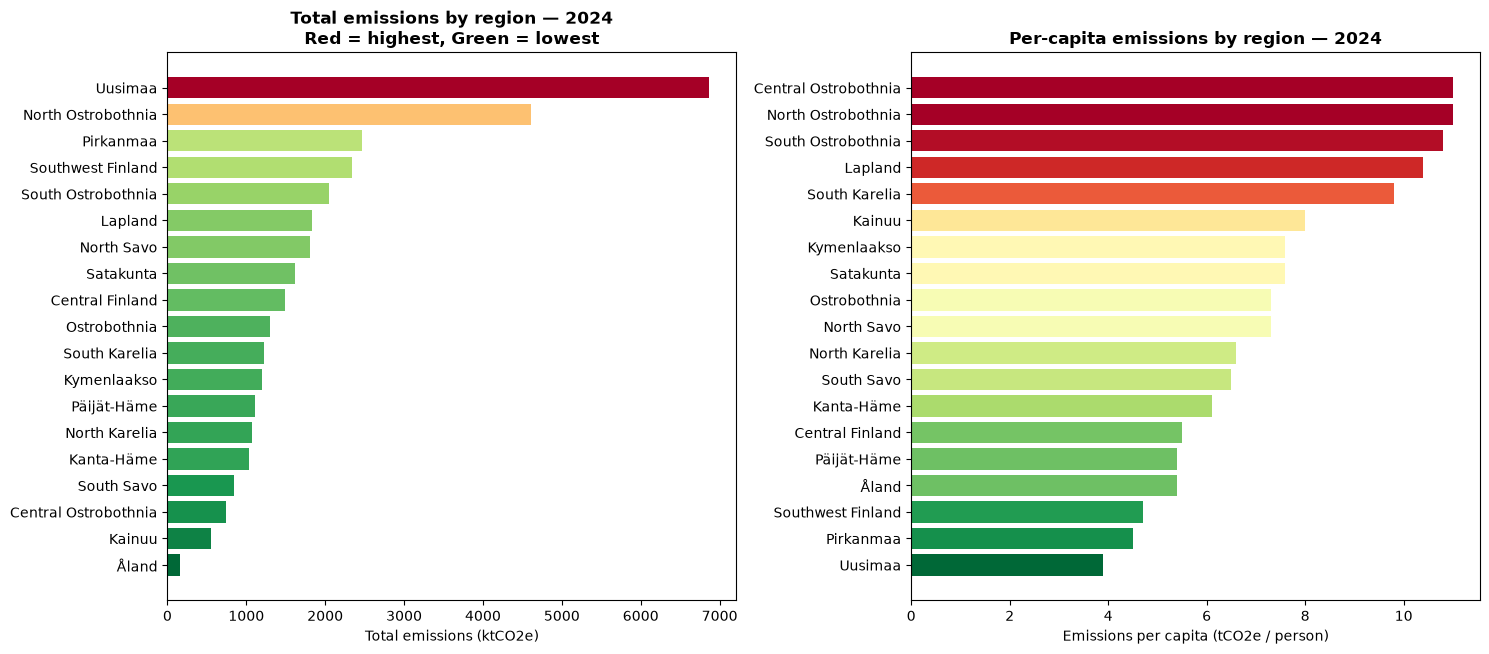

In [25]:
latest = summary[summary["year"] == FOCUS_YEAR].sort_values("total_ktco2e", ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(15, max(5, len(regions)*0.35)))

colors_total = cm.RdYlGn_r(mcolors.Normalize()(latest["total_ktco2e"]))
axes[0].barh(latest["region"], latest["total_ktco2e"], color=colors_total)
axes[0].invert_yaxis()
axes[0].set_xlabel("Total emissions (ktCO2e)")
axes[0].set_title(f"Total emissions by region — {FOCUS_YEAR}\nRed = highest, Green = lowest",
                   fontweight="bold")

latest_pc = summary[summary["year"] == FOCUS_YEAR].sort_values("per_capita_tco2e", ascending=False)
colors_pc = cm.RdYlGn_r(mcolors.Normalize()(latest_pc["per_capita_tco2e"]))
axes[1].barh(latest_pc["region"], latest_pc["per_capita_tco2e"], color=colors_pc)
axes[1].invert_yaxis()
axes[1].set_xlabel("Emissions per capita (tCO2e / person)")
axes[1].set_title(f"Per-capita emissions by region — {FOCUS_YEAR}", fontweight="bold")

plt.tight_layout()
plt.savefig(os.path.join(output_dir, "section2_latest_ranking.png"), dpi=130, bbox_inches="tight")
plt.show()


---
## 3 — Region Similarity: Correlation of Emission Trajectories
**Question:** which regions rise and fall together over time — i.e. share the same drivers
(same industry mix, same heating fuel mix, same weather sensitivity)?

We correlate each region's **year-over-year total emissions series** (1990–latest) against
every other region's. High positive correlation = regions decarbonising in the same pattern
(often same dominant sector, e.g. two industrial regions both affected by a paper mill closure
or an electricity-grid decarbonisation that benefits everyone at a similar rate).


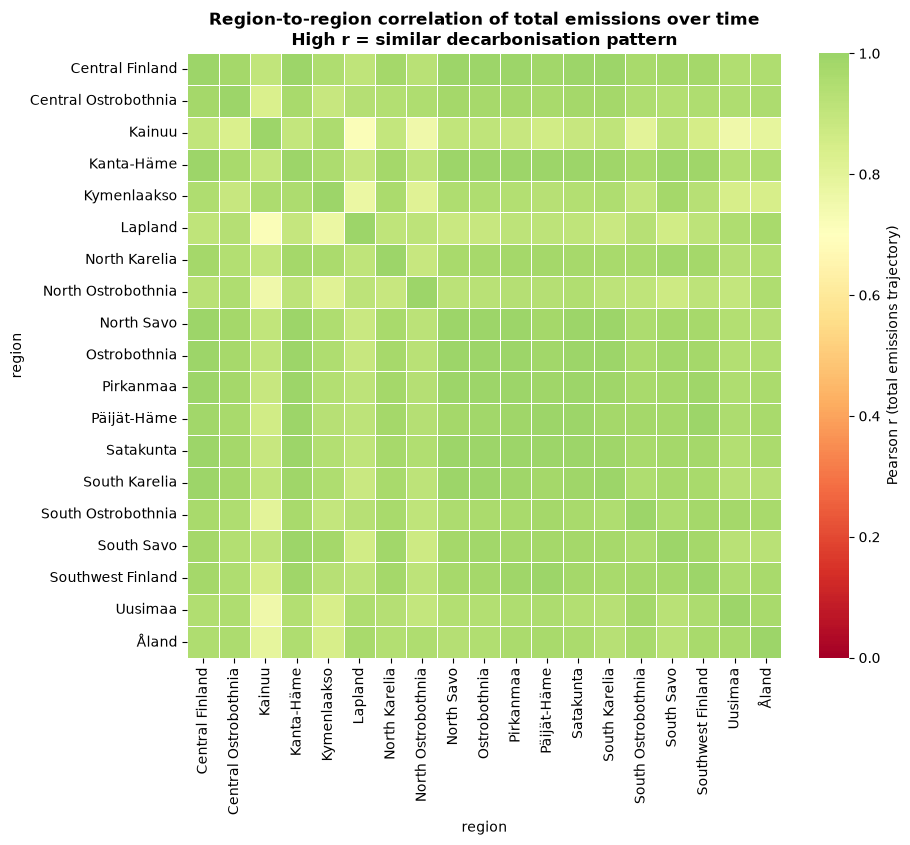

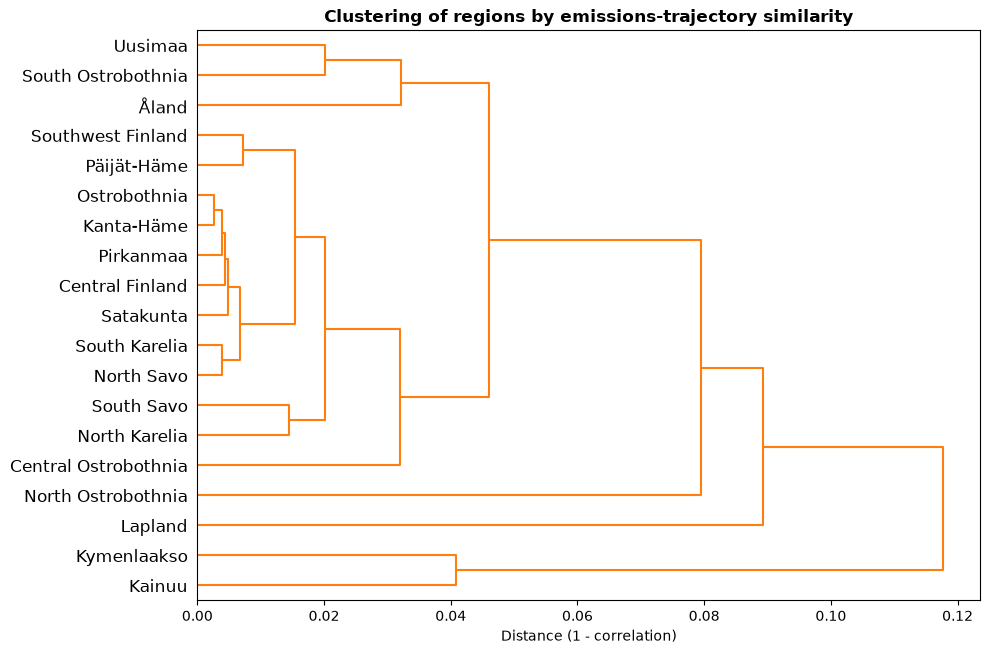

Most similar region pairs:
region           region       
Kanta-Häme       Ostrobothnia     0.997380
Ostrobothnia     Pirkanmaa        0.996711
Central Finland  Kanta-Häme       0.996283
North Savo       South Karelia    0.996101
                 Ostrobothnia     0.995885
Kanta-Häme       Pirkanmaa        0.995663
Pirkanmaa        Satakunta        0.995633
Central Finland  North Savo       0.995570
                 Ostrobothnia     0.995379
Kanta-Häme       North Savo       0.995319
dtype: float64


In [4]:
pivot_total = summary.pivot_table(index="year", columns="region", values="total_ktco2e")

if pivot_total.shape[1] < 2:
    print("Need at least 2 regions to compute correlation. Add more files and re-run.")
else:
    corr = pivot_total.corr()

    fig, ax = plt.subplots(figsize=(max(8, len(regions)*0.5), max(7, len(regions)*0.45)))
    sns.heatmap(corr, cmap="RdYlGn", center=0.7, vmin=0, vmax=1, annot=(len(regions) <= 12),
                fmt=".2f", linewidths=0.4, ax=ax,
                cbar_kws={"label": "Pearson r (total emissions trajectory)"})
    ax.set_title("Region-to-region correlation of total emissions over time\n"
                 "High r = similar decarbonisation pattern", fontweight="bold")
    plt.tight_layout()
    plt.savefig(os.path.join(output_dir, "section3_correlation_heatmap.png"), dpi=130, bbox_inches="tight")
    plt.show()

    # Hierarchical clustering — group regions with similar trajectories
    dist = 1 - corr
    condensed = squareform(dist.values, checks=False)
    Z = linkage(condensed, method="average")

    fig, ax = plt.subplots(figsize=(10, max(5, len(regions)*0.35)))
    dendrogram(Z, labels=corr.columns.tolist(), orientation="right", ax=ax,
               color_threshold=0.3)
    ax.set_title("Clustering of regions by emissions-trajectory similarity",
                fontweight="bold")
    ax.set_xlabel("Distance (1 - correlation)")
    plt.tight_layout()
    plt.savefig(os.path.join(output_dir, "section3_dendrogram.png"), dpi=130, bbox_inches="tight")
    plt.show()

    print("Most similar region pairs:")
    corr_flat = corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool)).stack()
    print(corr_flat.sort_values(ascending=False).head(10))


---
## 4 — Choropleth Map of Finland
**Colours regions by total (or per-capita) emissions — red = highest, green = lowest.**

This needs region *boundary geometry*, which isn't in the emissions data. Statistics Finland
publishes it as a free WFS service. This cell tries to fetch it live; if you have no internet
access or `geopandas` isn't installed, it automatically falls back to a labelled ranking chart
(Section 2 already gives you that data — this just tries to also give you a real map).

```
pip install geopandas requests
```


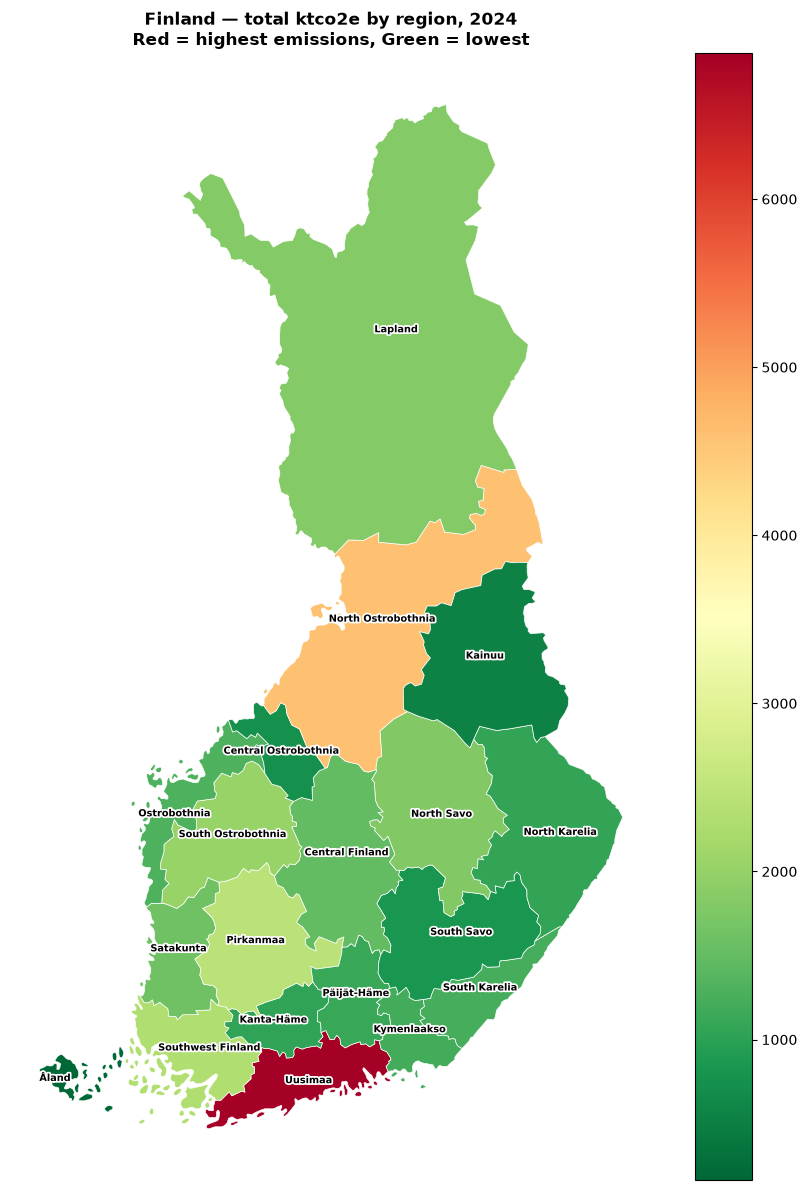

In [5]:
MAP_METRIC = "total_ktco2e"   # or "per_capita_tco2e"

try:
    geo = fetch_region_geometry()
    name_col = geo["geo_name_col"].iloc[0]

    latest_map = latest.copy()
    latest_map["region_key"] = latest_map["region"].apply(normalize_name)

    merged_geo = geo.merge(latest_map, on="region_key", how="left")

    fig, ax = plt.subplots(figsize=(9, 12))
    merged_geo.plot(column=MAP_METRIC, cmap="RdYlGn_r", legend=True, ax=ax,
                     edgecolor="white", linewidth=0.5,
                     missing_kwds={"color": "lightgrey", "label": "No data yet"})

    # Label each region. representative_point() (not centroid!) is guaranteed to
    # fall INSIDE the polygon -- centroid can land outside for oddly-shaped or
    # multi-part regions (e.g. the Aland archipelago is many small islands, whose
    # centroid can fall in open water between them).
    label_points = merged_geo.geometry.representative_point()
    for point, geo_name, region_name in zip(label_points, merged_geo[name_col], merged_geo["region"]):
        display_name = region_name if pd.notna(region_name) else geo_name
        ax.annotate(display_name, xy=(point.x, point.y), ha="center", va="center",
                    fontsize=7, fontweight="bold", color="black",
                    path_effects=[pe.withStroke(linewidth=2.5, foreground="white")])

    ax.set_title(f"Finland — {MAP_METRIC.replace('_',' ')} by region, {FOCUS_YEAR}\n"
                 "Red = highest emissions, Green = lowest", fontweight="bold")
    ax.set_axis_off()
    plt.tight_layout()
    plt.savefig(os.path.join(output_dir, "section4_choropleth_map.png"), dpi=150, bbox_inches="tight")
    plt.show()

except Exception as e:
    print(f"Map fetch failed ({e}). Falling back to ranked bar chart (see Section 2 for the "
          f"full-color version) — this is the same information, just without geometry.")
    fig, ax = plt.subplots(figsize=(10, max(5, len(regions)*0.35)))
    colors = cm.RdYlGn_r(mcolors.Normalize()(latest[MAP_METRIC]))
    ax.barh(latest["region"], latest[MAP_METRIC], color=colors)
    ax.invert_yaxis()
    ax.set_title(f"{MAP_METRIC.replace('_',' ')} by region, {FOCUS_YEAR} (map fallback)",
                fontweight="bold")
    plt.tight_layout()
    plt.show()


---
## 5 — GDP vs CO₂ Over Time
**Goal:** show, in a way that doesn't require reading bubble sizes and colours at once, whether
each region is growing its economy while cutting emissions ("decoupling"), growing both, or
cutting both.

**First, the two GDP columns and their units — this is what caused the confusion:**

| Column | What it is | Unit | When to use it |
|---|---|---|---|
| `gdp_per_capita_eur` ("At current prices, euro") | **Nominal** GDP per person | EUR, in that year's own prices | Comparing regions **within the same year** (e.g. the FOCUS_YEAR snapshot). Don't use it to compare across years — €30,000 in 2005 and €30,000 in 2023 don't buy the same amount, because prices rose in between. |
| `gdp_per_capita_real_2015eur` ("Volume series, reference year 2015") | **Real / inflation-adjusted** GDP per person | EUR, held at constant 2015 price levels | Comparing the **same region across years** or **plotting a time trend** — this is "real growth", with inflation stripped out, so a rising line means the economy actually produced more, not just that prices went up. |

We use the **real** series for anything that spans multiple years (the trend panels and the
BASE_YEAR→COMPARE_YEAR trajectory below), and the **nominal** series only for the FOCUS_YEAR view
where everyone is compared at the same point in time and inflation isn't a factor.

**Three views, easiest to hardest:**
1. Two side-by-side trend panels — GDP and CO2 per capita over time, same x-axis, so you can
   visually line up "when did GDP take off" against "when did CO2 fall" per region, without any
   bubble-size/colour decoding.
2. A trajectory chart — each region as one arrow from `BASE_YEAR` to `COMPARE_YEAR`, in
   (GDP per capita, CO2 per capita) space. An arrow pointing **right and down** = grew richer
   AND cut emissions (real decoupling). Right and up = grew but got dirtier. Left and down =
   shrank but also cut emissions.
3. Carbon intensity of GDP over time (kept from before) — tCO2e per million EUR of *nominal*
   GDP. This one mixes a real quantity (tonnes) with a nominal one (euros), which is standard
   practice for this metric internationally, but it means a falling line can partly reflect
   inflation raising the euro figure rather than only emissions falling — treat it as a
   secondary, confirmatory chart rather than the primary "decoupling" evidence (that's #2).


In [6]:
if gdp_merged is None:
    print("Run 02_merge_gdp.py first to populate region_year_with_gdp.")
elif gdp_merged["gdp_per_capita_eur"].notna().sum() == 0:
    print("region_year_with_gdp has no non-null GDP values yet -- check the "
          "'no GDP match' warning printed by 02_merge_gdp.py (region name mismatch?).")
else:
    gdp_years_available = gdp_merged.dropna(subset=["gdp_per_capita_eur"])["year"]
    LATEST_GDP_YEAR = int(gdp_years_available.max())
    EFFECTIVE_COMPARE_YEAR = min(COMPARE_YEAR, LATEST_GDP_YEAR)
    if EFFECTIVE_COMPARE_YEAR != COMPARE_YEAR:
        print(f"Note: COMPARE_YEAR={COMPARE_YEAR} has no GDP data yet (GDP data ends "
              f"{LATEST_GDP_YEAR}). Using {EFFECTIVE_COMPARE_YEAR} for the GDP sections below.")
    print(f"Using BASE_YEAR={BASE_YEAR}  COMPARE_YEAR={EFFECTIVE_COMPARE_YEAR} (GDP-adjusted)")


Note: COMPARE_YEAR=2024 has no GDP data yet (GDP data ends 2023). Using 2023 for the GDP sections below.
Using BASE_YEAR=2005  COMPARE_YEAR=2023 (GDP-adjusted)


### 5a — GDP and CO2 trends side by side

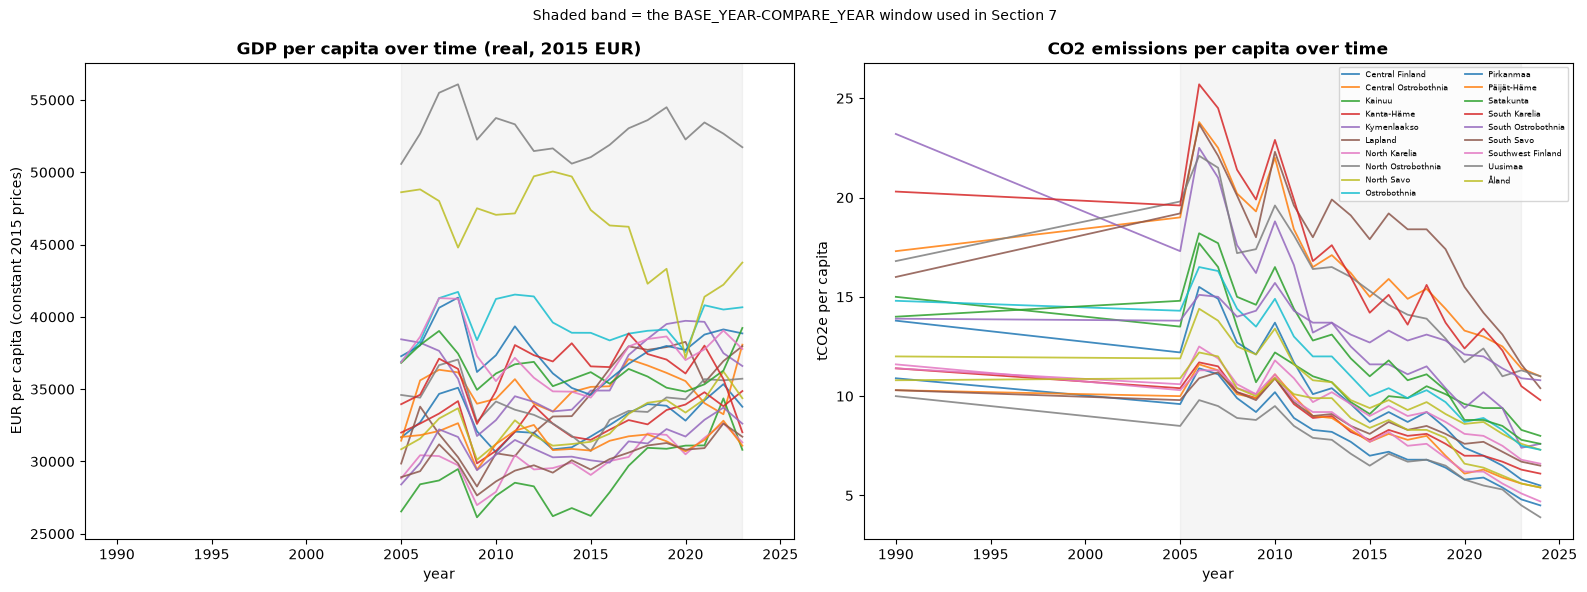

In [7]:
if gdp_merged is not None and gdp_merged["gdp_per_capita_eur"].notna().sum() > 0:
    fig, axes = plt.subplots(1, 2, figsize=(16, 6), sharex=True)

    gdp_pivot = gdp_merged.pivot_table(index="year", columns="region",
                                       values="gdp_per_capita_real_2015eur")
    co2_pivot = gdp_merged.pivot_table(index="year", columns="region", values="per_capita_tco2e")

    gdp_pivot.plot(ax=axes[0], lw=1.3, alpha=0.85, legend=False)
    axes[0].set_title("GDP per capita over time (real, 2015 EUR)", fontweight="bold")
    axes[0].set_ylabel("EUR per capita (constant 2015 prices)")
    axes[0].axvspan(BASE_YEAR, EFFECTIVE_COMPARE_YEAR, color="grey", alpha=0.08)

    co2_pivot.plot(ax=axes[1], lw=1.3, alpha=0.85, legend=(len(regions) <= 12))
    axes[1].set_title("CO2 emissions per capita over time", fontweight="bold")
    axes[1].set_ylabel("tCO2e per capita")
    axes[1].axvspan(BASE_YEAR, EFFECTIVE_COMPARE_YEAR, color="grey", alpha=0.08)
    if len(regions) > 12:
        axes[1].legend(fontsize=6, ncol=2, loc="upper right")

    plt.suptitle("Shaded band = the BASE_YEAR-COMPARE_YEAR window used in Section 7",
                 fontsize=10)
    plt.tight_layout()
    plt.savefig(os.path.join(output_dir, "section5a_gdp_co2_trends.png"), dpi=130, bbox_inches="tight")
    plt.show()


### 5b — Trajectory: where each region moved between BASE_YEAR and COMPARE_YEAR

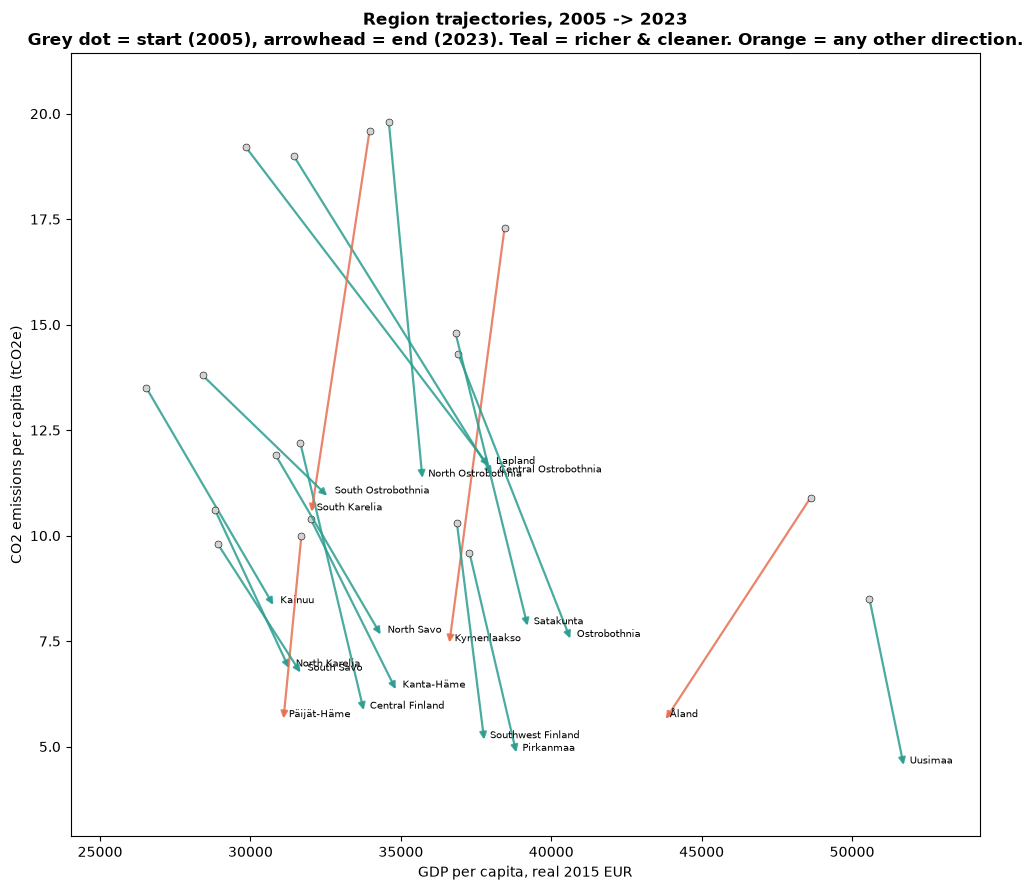

In [8]:
if gdp_merged is not None and gdp_merged["gdp_per_capita_eur"].notna().sum() > 0:
    traj = gdp_merged[gdp_merged["year"].isin([BASE_YEAR, EFFECTIVE_COMPARE_YEAR])].dropna(
        subset=["gdp_per_capita_real_2015eur", "per_capita_tco2e"])

    fig, ax = plt.subplots(figsize=(10, 9))
    for region, g in traj.groupby("region"):
        g = g.sort_values("year")
        if len(g) < 2:
            continue
        x0, y0 = g.iloc[0][["gdp_per_capita_real_2015eur", "per_capita_tco2e"]]
        x1, y1 = g.iloc[1][["gdp_per_capita_real_2015eur", "per_capita_tco2e"]]
        decoupling = x1 > x0 and y1 < y0   # richer AND cleaner
        color = "#2a9d8f" if decoupling else "#e76f51"
        ax.annotate("", xy=(x1, y1), xytext=(x0, y0),
                    arrowprops=dict(arrowstyle="-|>", color=color, lw=1.6, alpha=0.85))
        ax.scatter([x0], [y0], color="lightgrey", s=25, zorder=3, edgecolor="black", linewidth=0.4)
        ax.annotate(region, (x1, y1), fontsize=7, xytext=(4, 3), textcoords="offset points")

    # ax.annotate()'s arrowprops does NOT feed matplotlib's axis autoscaling (only
    # plot()/scatter() calls do) -- without this, the view stays zoomed to whatever
    # WAS scattered (the start points only) and every arrow can end up drawn off-screen.
    if len(traj):
        x_pad = (traj["gdp_per_capita_real_2015eur"].max() - traj["gdp_per_capita_real_2015eur"].min()) * 0.1 + 1
        y_pad = (traj["per_capita_tco2e"].max() - traj["per_capita_tco2e"].min()) * 0.1 + 0.1
        ax.set_xlim(traj["gdp_per_capita_real_2015eur"].min() - x_pad,
                    traj["gdp_per_capita_real_2015eur"].max() + x_pad)
        ax.set_ylim(traj["per_capita_tco2e"].min() - y_pad,
                    traj["per_capita_tco2e"].max() + y_pad)

    ax.set_xlabel("GDP per capita, real 2015 EUR")
    ax.set_ylabel("CO2 emissions per capita (tCO2e)")
    ax.set_title(f"Region trajectories, {BASE_YEAR} -> {EFFECTIVE_COMPARE_YEAR}\n"
                 "Grey dot = start ({0}), arrowhead = end ({1}). "
                 "Teal = richer & cleaner. Orange = any other direction.".format(
                     BASE_YEAR, EFFECTIVE_COMPARE_YEAR),
                 fontweight="bold")
    plt.tight_layout()
    plt.savefig(os.path.join(output_dir, "section5b_trajectory.png"), dpi=130, bbox_inches="tight")
    plt.show()


### 5c — Carbon intensity of GDP over time
`co2_tonnes_per_million_eur_gdp` = tonnes CO2e per million EUR of **nominal** GDP. It answers
"how carbon-heavy is this region's economy, independent of its size?" -- a big region and a
small region can have very different totals but the same intensity if their industry mix is
similar. Falling intensity means the region produces more value per tonne of CO2 than before.


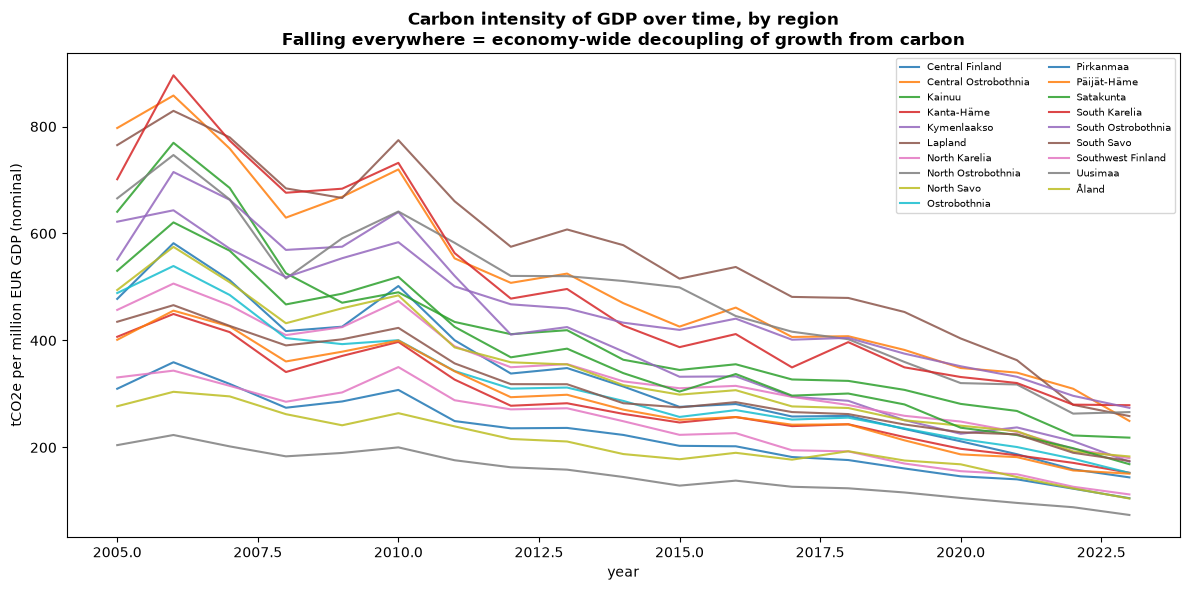

In [9]:
if gdp_merged is not None and gdp_merged["gdp_per_capita_eur"].notna().sum() > 0:
    intensity_pivot = gdp_merged.pivot_table(index="year", columns="region",
                                             values="co2_tonnes_per_million_eur_gdp")
    fig, ax = plt.subplots(figsize=(12, 6))
    intensity_pivot.plot(ax=ax, lw=1.5, alpha=0.85, legend=(len(regions) <= 12))
    ax.set_ylabel("tCO2e per million EUR GDP (nominal)")
    ax.set_title("Carbon intensity of GDP over time, by region\n"
                 "Falling everywhere = economy-wide decoupling of growth from carbon",
                 fontweight="bold")
    if len(regions) > 12:
        ax.legend(fontsize=7, ncol=2, loc="upper right")
    plt.tight_layout()
    plt.savefig(os.path.join(output_dir, "section5c_carbon_intensity_trend.png"), dpi=130, bbox_inches="tight")
    plt.show()


---
## 6 — Sectoral Carbon Economy: Breakdown, Evolution & Subclass Drill-Down
### 6a — Which sector dominates emissions in each region (`FOCUS_YEAR`)
A region whose emissions are mostly `Road transport` + `Agriculture` has a very different
decarbonisation path from one dominated by `Industry` + `District heating`.


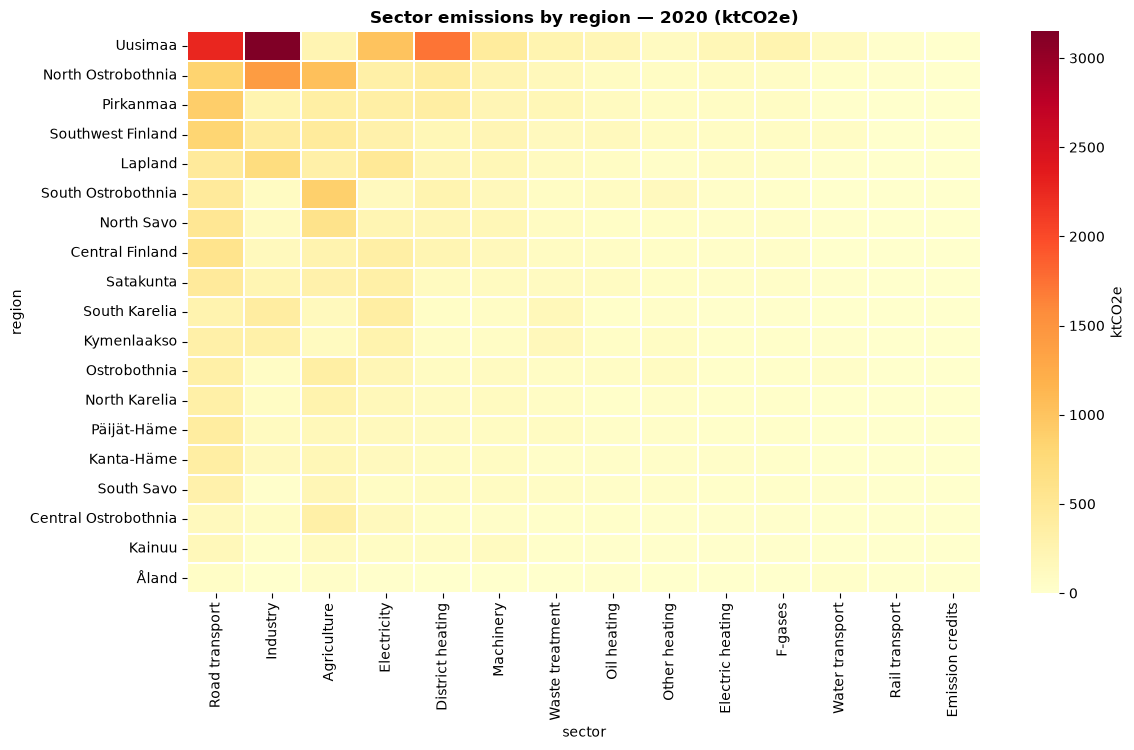

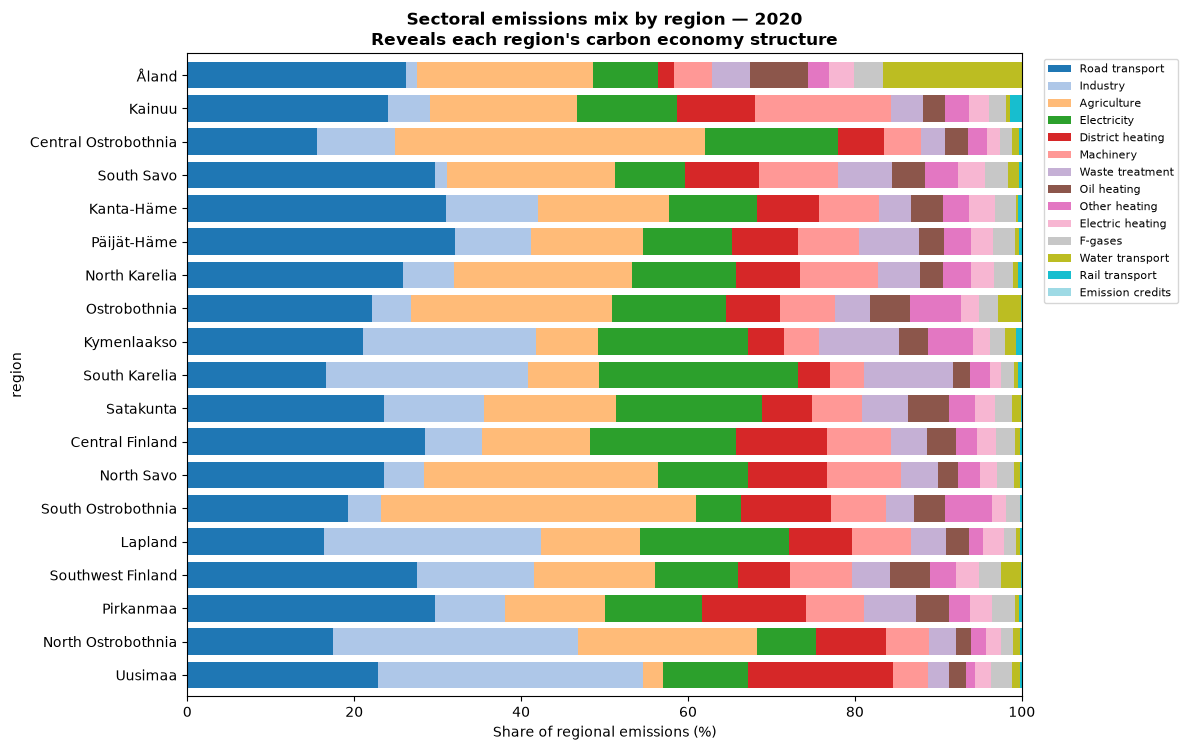

In [26]:
FOCUS_YEAR = 2020
latest_sectors = ghg_long[ghg_long["year"] == FOCUS_YEAR]
sector_pivot = latest_sectors.pivot_table(index="region", columns="sector",
                                          values="value_ktco2e", aggfunc="sum").fillna(0)

# Order regions by total, sectors by national total (most important sector first)
sector_pivot = sector_pivot.loc[sector_pivot.sum(axis=1).sort_values(ascending=False).index]
sector_order = sector_pivot.sum(axis=0).sort_values(ascending=False).index
sector_pivot = sector_pivot[sector_order]

fig, ax = plt.subplots(figsize=(12, max(6, len(regions)*0.4)))
sns.heatmap(sector_pivot, cmap="YlOrRd", annot=(len(regions) <= 12), fmt=".0f",
            linewidths=0.3, ax=ax, cbar_kws={"label": "ktCO2e"})
ax.set_title(f"Sector emissions by region — {FOCUS_YEAR} (ktCO2e)", fontweight="bold")
plt.tight_layout()
plt.savefig(os.path.join(output_dir, "section6a_sector_heatmap.png"), dpi=130, bbox_inches="tight")
plt.show()

# Share of each sector within each region (normalised rows) — shows economic structure
sector_share = sector_pivot.div(sector_pivot.sum(axis=1), axis=0) * 100
fig, ax = plt.subplots(figsize=(12, max(6, len(regions)*0.4)))
sector_share.plot(kind="barh", stacked=True, ax=ax, colormap="tab20", width=0.8)
ax.set_xlabel("Share of regional emissions (%)")
ax.set_title(f"Sectoral emissions mix by region — {FOCUS_YEAR}\n"
             "Reveals each region's carbon economy structure", fontweight="bold")
ax.legend(bbox_to_anchor=(1.02, 1), loc="upper left", fontsize=8)
plt.tight_layout()
plt.savefig(os.path.join(output_dir, "section6a_sector_share.png"), dpi=130, bbox_inches="tight")
plt.show()


### 6b — How each sector is evolving over time (national total, all loaded regions)
Answers "for each year, how is each sector changing?" — a stacked area chart of every sector's
combined emissions across all loaded regions, year by year. This is the piece that lets you say
*which* sectors are actually driving the national decline, rather than only observing that the
total fell.


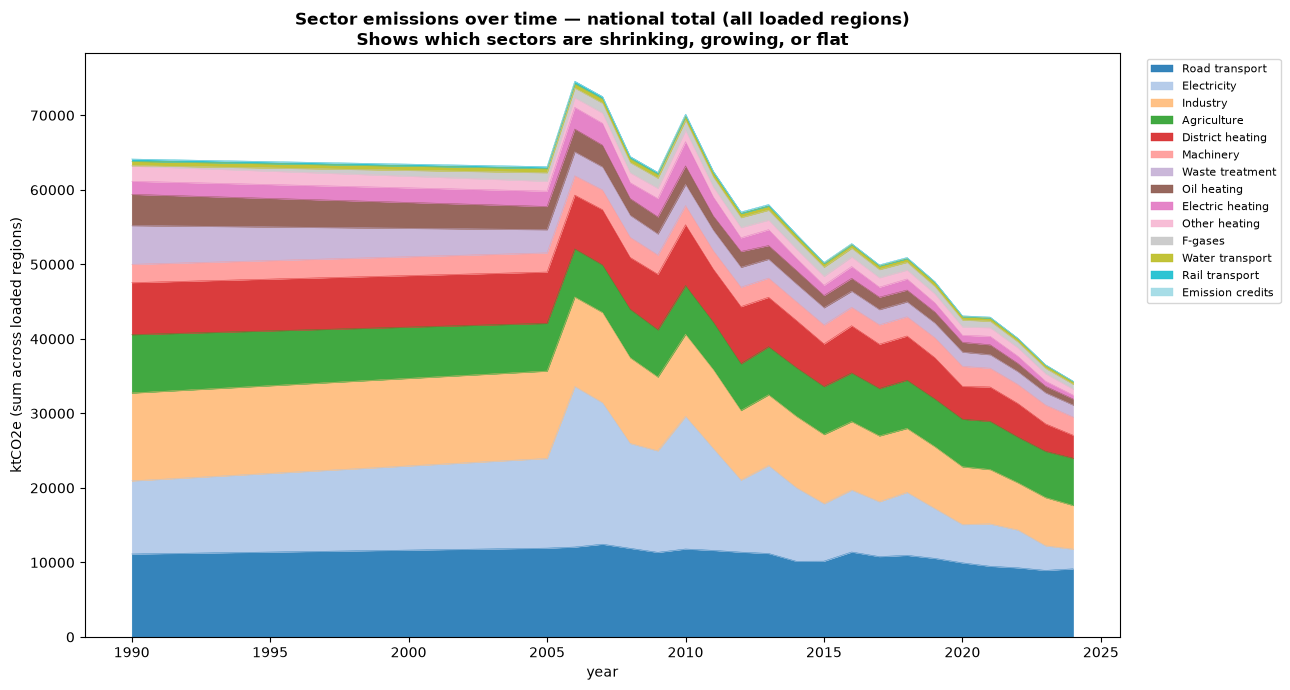

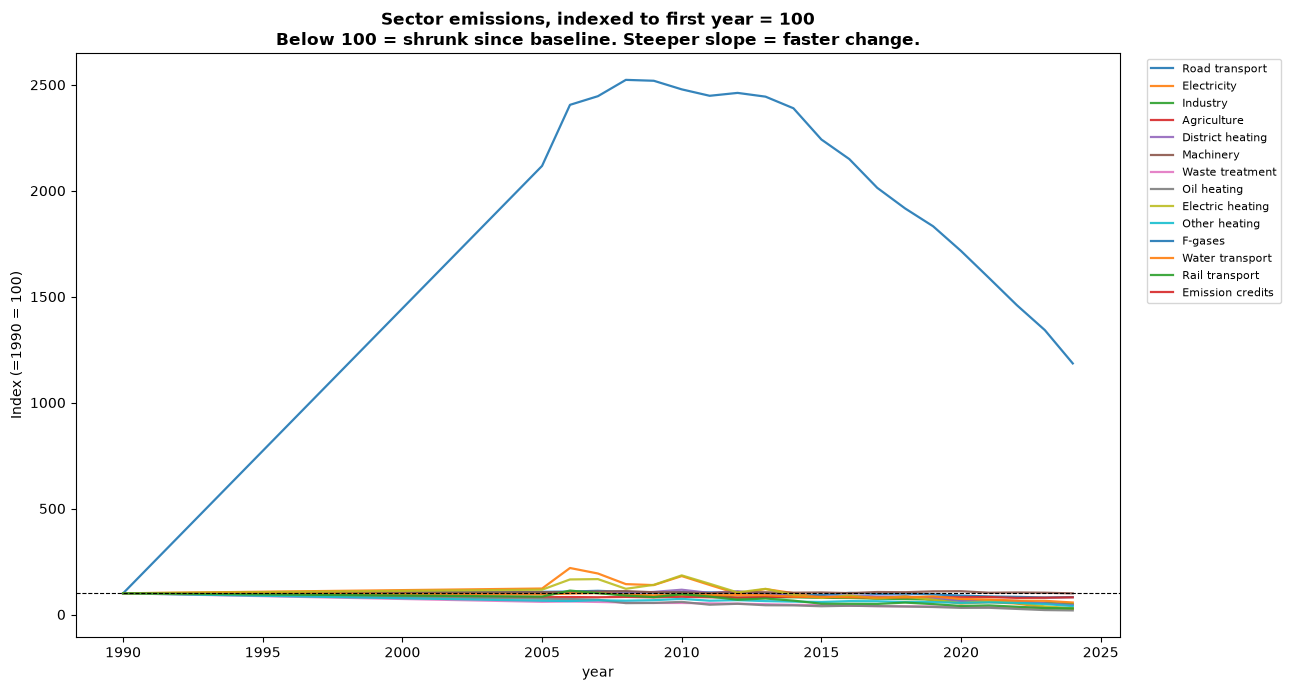

In [ ]:

national_sector_year = (ghg_long.groupby(["year","sector"])["value_ktco2e"]
                        .sum().reset_index()
                        .pivot(index="year", columns="sector", values="value_ktco2e"))
sector_order_time = national_sector_year.sum(axis=0).sort_values(ascending=False).index
national_sector_year = national_sector_year[sector_order_time]

fig, ax = plt.subplots(figsize=(13, 7))
national_sector_year.plot.area(ax=ax, cmap="tab20", alpha=0.9, linewidth=0.3)
ax.set_ylabel("ktCO2e (sum across loaded regions)")
ax.set_title("Sector emissions over time — national total (all loaded regions)\n"
             "Shows which sectors are shrinking, growing, or flat", fontweight="bold")
ax.legend(bbox_to_anchor=(1.02, 1), loc="upper left", fontsize=8)
plt.tight_layout()
plt.savefig(os.path.join(output_dir, "section6b_sector_evolution_area.png"), dpi=130, bbox_inches="tight")
plt.show()

# Same data, as % change from the first year each sector appears -- easier to see relative speed
sector_indexed = national_sector_year / national_sector_year.iloc[0] * 100
fig, ax = plt.subplots(figsize=(13, 7))
sector_indexed.plot(ax=ax, lw=1.6, alpha=0.9)
ax.axhline(100, color="black", lw=0.8, linestyle="--")
ax.set_ylabel(f"Index (={national_sector_year.index[0]} = 100)")
ax.set_title("Sector emissions, indexed to first year = 100\n"
             "Below 100 = shrunk since baseline. Steeper slope = faster change.",
             fontweight="bold")
ax.legend(bbox_to_anchor=(1.02, 1), loc="upper left", fontsize=8)
plt.tight_layout()
plt.savefig(os.path.join(output_dir, "section6b_sector_evolution_indexed.png"), dpi=130, bbox_inches="tight")
plt.show()


### 6c — Subclass drill-down: what's really inside a sector?
`SUBCLASS_REGION` and `SUBCLASS_SECTOR` below pick which region+sector to open up. By default it
auto-picks the region's single largest sector in `FOCUS_YEAR` so this always runs out of the box —
change either variable to inspect a different region/sector.


Drilling into: Kymenlaakso / Road transport


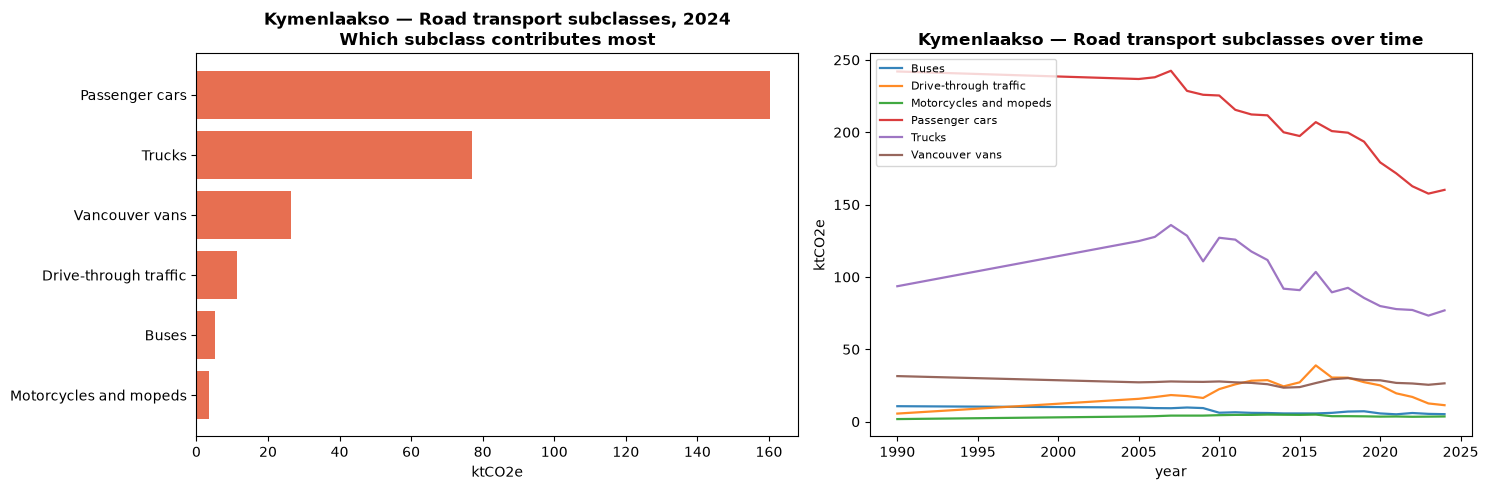

In [30]:
FOCUS_YEAR = 2024
if subclass_emissions is None:
    print("Subclass tables not loaded -- re-run the updated 01_consolidate_regions.py.")
else:
    SUBCLASS_REGION = "Kymenlaakso"                 # <- change to any loaded region name
    SUBCLASS_SECTOR = None                       # <- None = auto-pick the region's top sector

    region_focus_sectors = ghg_long[(ghg_long["region"] == SUBCLASS_REGION)
                                    & (ghg_long["year"] == FOCUS_YEAR)]
    if SUBCLASS_SECTOR is None and len(region_focus_sectors):
        SUBCLASS_SECTOR = region_focus_sectors.sort_values("value_ktco2e", ascending=False)["sector"].iloc[0]
    print(f"Drilling into: {SUBCLASS_REGION} / {SUBCLASS_SECTOR}")

    sub = subclass_emissions[(subclass_emissions["region"] == SUBCLASS_REGION)
                             & (subclass_emissions["sector"].str.strip() == str(SUBCLASS_SECTOR).strip())]

    if sub.empty:
        print("No subclass rows matched -- check SUBCLASS_REGION/SUBCLASS_SECTOR spelling.")
    else:
        # Which subclass contributes most, in FOCUS_YEAR
        focus_sub = sub[sub["year"] == FOCUS_YEAR].sort_values("value_ktco2e", ascending=False)
        fig, axes = plt.subplots(1, 2, figsize=(15, 5))

        axes[0].barh(focus_sub["subclass"], focus_sub["value_ktco2e"], color="#e76f51")
        axes[0].invert_yaxis()
        axes[0].set_xlabel("ktCO2e")
        axes[0].set_title(f"{SUBCLASS_REGION} — {SUBCLASS_SECTOR} subclasses, {FOCUS_YEAR}\n"
                          "Which subclass contributes most", fontweight="bold")

        sub_pivot = sub.pivot_table(index="year", columns="subclass", values="value_ktco2e")
        sub_pivot.plot(ax=axes[1], lw=1.6, alpha=0.9)
        axes[1].set_ylabel("ktCO2e")
        axes[1].set_title(f"{SUBCLASS_REGION} — {SUBCLASS_SECTOR} subclasses over time",
                          fontweight="bold")
        axes[1].legend(fontsize=8)

        plt.tight_layout()
        plt.savefig(os.path.join(output_dir, "section6c_subclass_drilldown.png"), dpi=130, bbox_inches="tight")
        plt.show()


---
## 7 — Decarbonisation: Ranking, Year-on-Year Change, Rate of Change, and What's Driving It
### 7a — Ranking, `BASE_YEAR` → `COMPARE_YEAR`
Which regions cut emissions fastest (%) between the two years set in the Parameters cell —
change `BASE_YEAR`/`COMPARE_YEAR` there to compare any two years, not just 2005-to-latest.


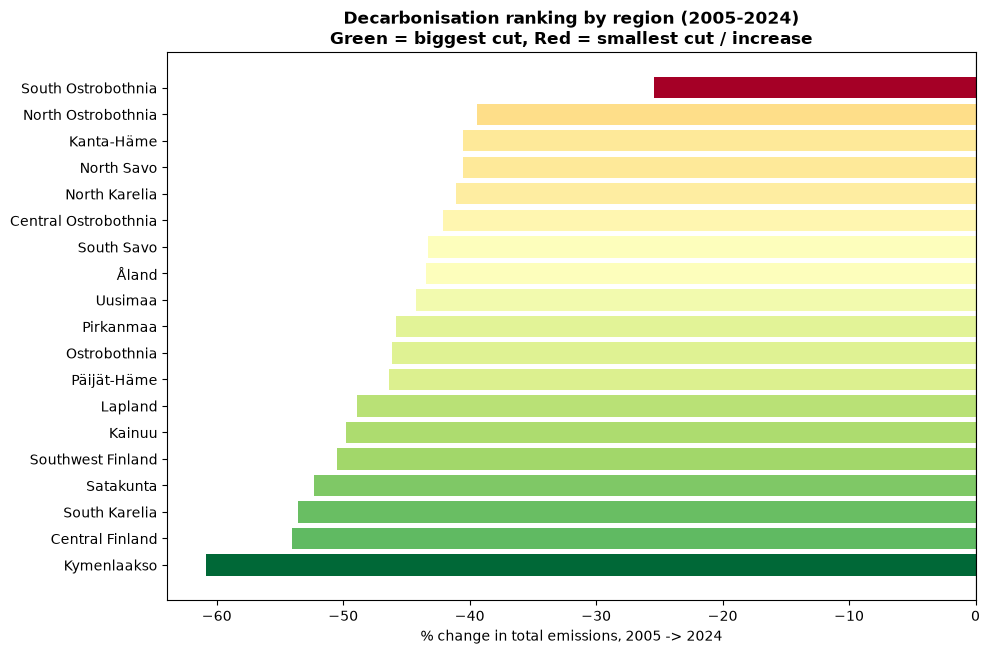

              region    base  latest  pct_change
         Kymenlaakso  3069.7  1201.6  -60.856110
     Central Finland  3252.1  1495.6  -54.011254
       South Karelia  2638.3  1225.9  -53.534473
           Satakunta  3385.5  1615.6  -52.278836
   Southwest Finland  4714.5  2335.6  -50.459222
              Kainuu  1104.7   554.9  -49.769168
             Lapland  3574.1  1827.0  -48.882236
         Päijät-Häme  2068.0  1108.8  -46.382979
        Ostrobothnia  2412.7  1300.1  -46.114312
           Pirkanmaa  4546.4  2464.5  -45.792275
             Uusimaa 12317.8  6866.9  -44.252220
               Åland   290.9   164.6  -43.416982
          South Savo  1487.2   843.5  -43.282679
Central Ostrobothnia  1284.4   743.7  -42.097477
       North Karelia  1825.1  1075.0  -41.099118
          North Savo  3049.3  1813.2  -40.537172
          Kanta-Häme  1742.8  1036.4  -40.532476
  North Ostrobothnia  7608.7  4610.0  -39.411463
  South Ostrobothnia  2744.4  2046.5  -25.429966


In [13]:
change = (summary[summary["year"] == BASE_YEAR][["region","total_ktco2e"]]
          .rename(columns={"total_ktco2e":"base"})
          .merge(summary[summary["year"] == COMPARE_YEAR][["region","total_ktco2e"]]
                 .rename(columns={"total_ktco2e":"latest"}), on="region"))
change["pct_change"] = (change["latest"] - change["base"]) / change["base"] * 100
change = change.sort_values("pct_change")

fig, ax = plt.subplots(figsize=(10, max(5, len(regions)*0.35)))
colors = cm.RdYlGn_r(mcolors.Normalize(vmin=change["pct_change"].min(),
                                       vmax=change["pct_change"].max())(change["pct_change"]))
ax.barh(change["region"], change["pct_change"], color=colors)
ax.axvline(0, color="black", lw=0.8)
ax.set_xlabel(f"% change in total emissions, {BASE_YEAR} -> {COMPARE_YEAR}")
ax.set_title(f"Decarbonisation ranking by region ({BASE_YEAR}-{COMPARE_YEAR})\n"
             "Green = biggest cut, Red = smallest cut / increase", fontweight="bold")
plt.tight_layout()
plt.savefig(os.path.join(output_dir, "section7a_decarbonisation_ranking.png"), dpi=130, bbox_inches="tight")
plt.show()

print(change.to_string(index=False))


### 7b — Year-on-year change (any two years, at a glance)
A heatmap of % change from each year to the next, per region. Read any single cell as
"how much did this region change from the year before" — or pick any two columns to compare two
arbitrary years directly, which is the general version of the BASE_YEAR/COMPARE_YEAR comparison
above.


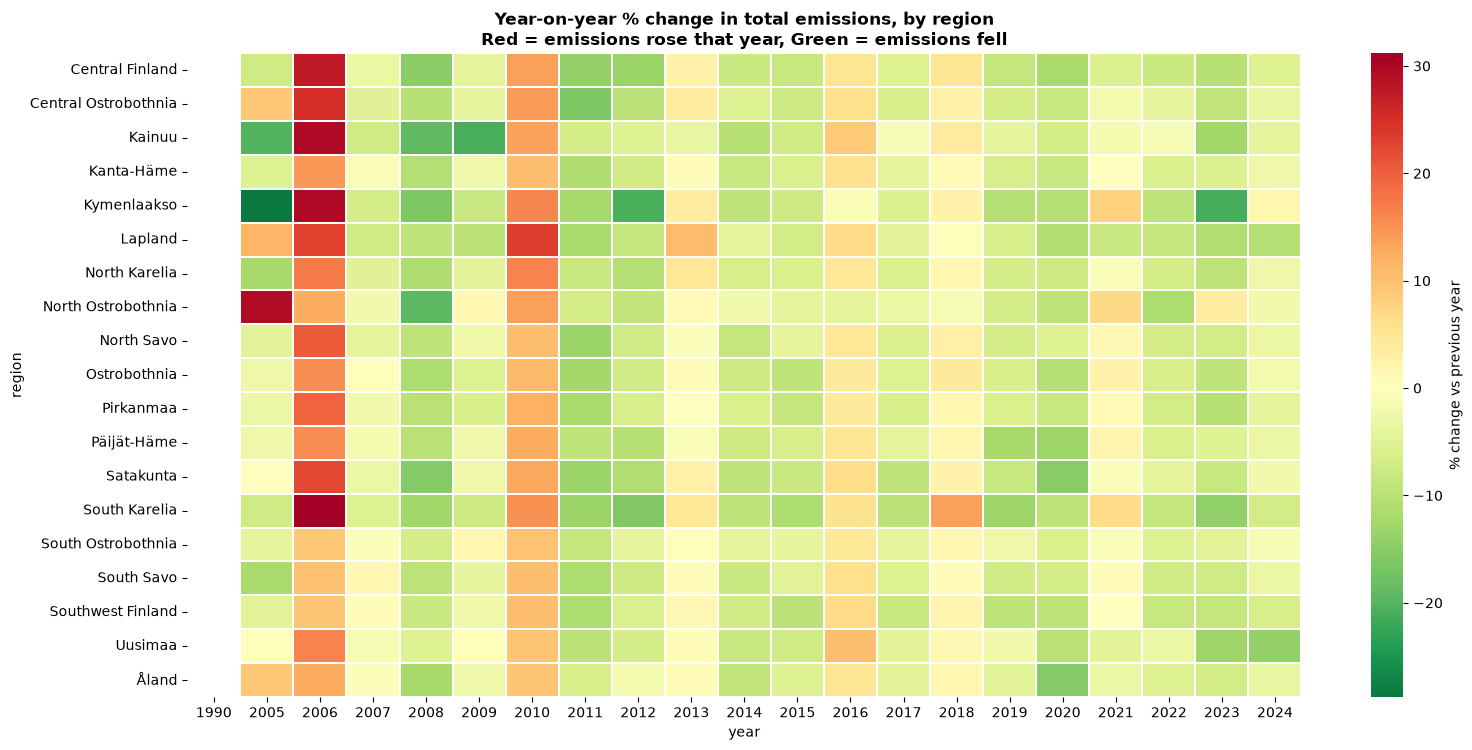


Direct comparison, 2005 vs 2024:
                         2005    2024  abs_change  pct_change
region                                                       
Kymenlaakso            3069.7  1201.6     -1868.1  -60.856110
Central Finland        3252.1  1495.6     -1756.5  -54.011254
South Karelia          2638.3  1225.9     -1412.4  -53.534473
Satakunta              3385.5  1615.6     -1769.9  -52.278836
Southwest Finland      4714.5  2335.6     -2378.9  -50.459222
Kainuu                 1104.7   554.9      -549.8  -49.769168
Lapland                3574.1  1827.0     -1747.1  -48.882236
Päijät-Häme            2068.0  1108.8      -959.2  -46.382979
Ostrobothnia           2412.7  1300.1     -1112.6  -46.114312
Pirkanmaa              4546.4  2464.5     -2081.9  -45.792275
Uusimaa               12317.8  6866.9     -5450.9  -44.252220
Åland                   290.9   164.6      -126.3  -43.416982
South Savo             1487.2   843.5      -643.7  -43.282679
Central Ostrobothnia   1284.4   743.

In [14]:
yoy_pivot = summary.pivot_table(index="region", columns="year", values="total_ktco2e")
yoy_pct = yoy_pivot.pct_change(axis=1) * 100

fig, ax = plt.subplots(figsize=(16, max(6, len(regions)*0.4)))
sns.heatmap(yoy_pct, cmap="RdYlGn_r", center=0, annot=False, linewidths=0.2, ax=ax,
            cbar_kws={"label": "% change vs previous year"})
ax.set_title("Year-on-year % change in total emissions, by region\n"
             "Red = emissions rose that year, Green = emissions fell", fontweight="bold")
plt.tight_layout()
plt.savefig(os.path.join(output_dir, "section7b_yoy_heatmap.png"), dpi=130, bbox_inches="tight")
plt.show()

# Direct two-year comparison table, using whatever years you want (not just BASE/COMPARE)
YEAR_A, YEAR_B = BASE_YEAR, COMPARE_YEAR   # <- change these to compare any two years directly
if YEAR_A in yoy_pivot.columns and YEAR_B in yoy_pivot.columns:
    two_year = pd.DataFrame({
        f"{YEAR_A}": yoy_pivot[YEAR_A],
        f"{YEAR_B}": yoy_pivot[YEAR_B],
        "abs_change": yoy_pivot[YEAR_B] - yoy_pivot[YEAR_A],
        "pct_change": (yoy_pivot[YEAR_B] - yoy_pivot[YEAR_A]) / yoy_pivot[YEAR_A] * 100,
    }).sort_values("pct_change")
    print(f"\nDirect comparison, {YEAR_A} vs {YEAR_B}:")
    print(two_year.to_string())


### 7c — Rate of change (the "derivative"): is decarbonisation speeding up or slowing down?
The ranking above only compares two endpoints, which can hide a lot: a region could have cut
emissions steadily, or done nothing for a decade and then cut sharply in one year. This plots the
**year-over-year rate of change itself** (ktCO2e/year, i.e. the first derivative of the emissions
curve) — negative and getting more negative = decarbonisation accelerating; negative but flattening
toward zero = decarbonisation stalling, even though the cumulative total is still falling.


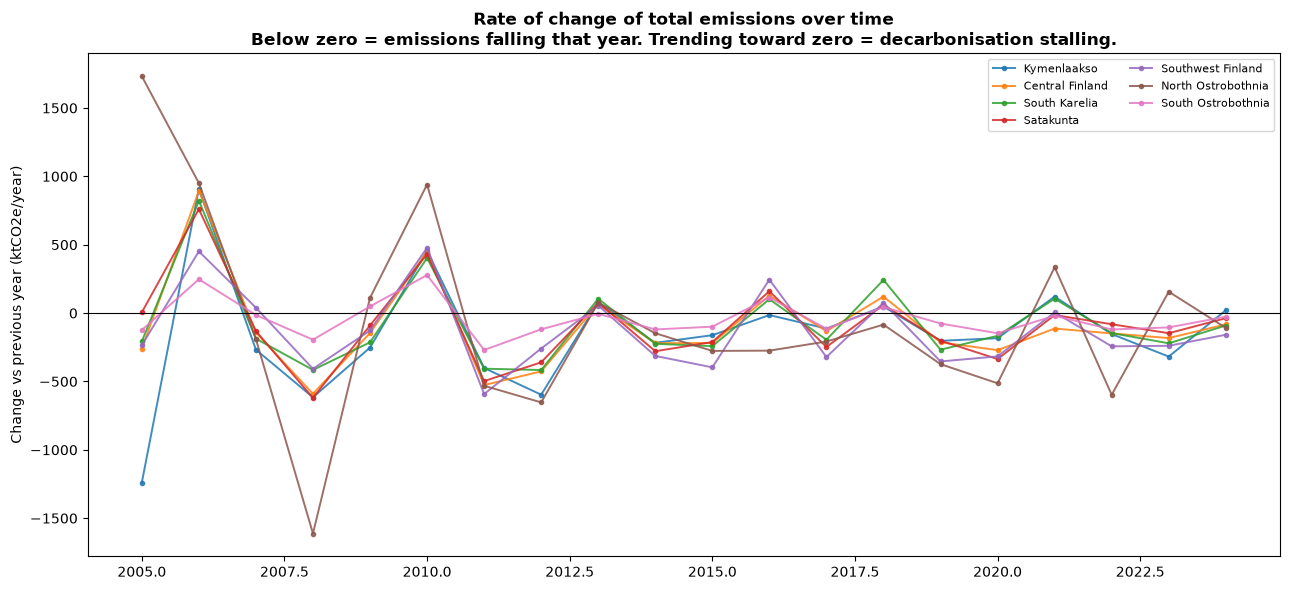

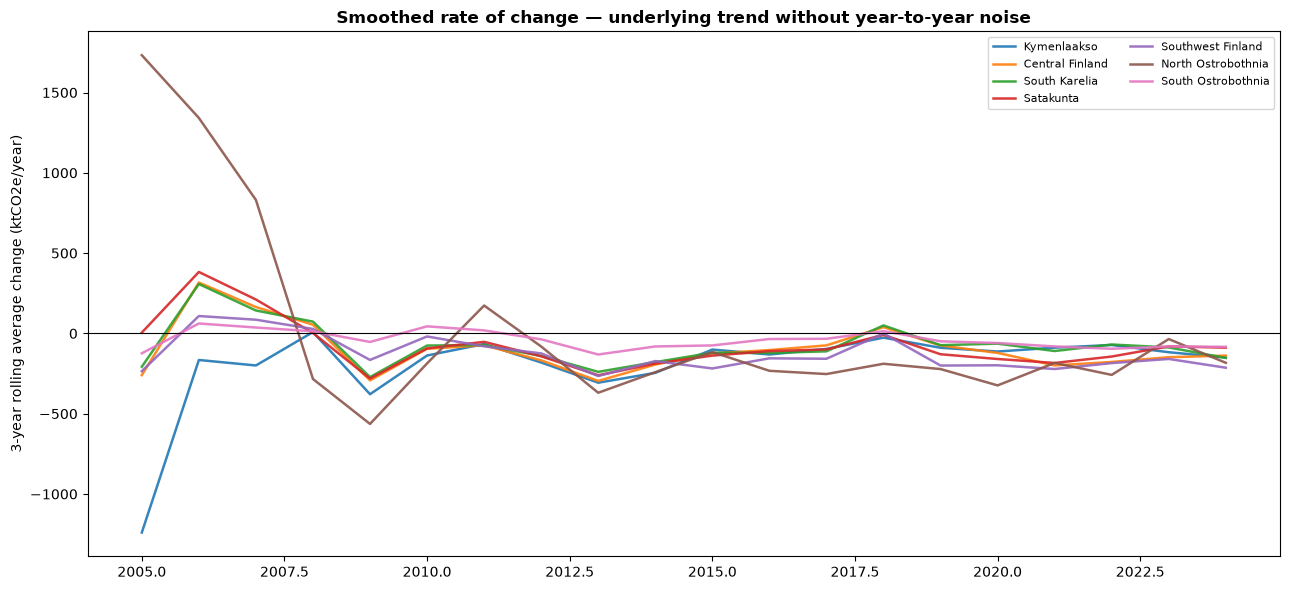

In [15]:
rate_of_change = yoy_pivot.diff(axis=1)   # ktCO2e change vs previous year, per region

# Focus on a handful of regions for readability -- default: the biggest movers from 7a
REGIONS_FOR_RATE_CHART = change["region"].head(5).tolist() + change["region"].tail(2).tolist()
fig, ax = plt.subplots(figsize=(13, 6))
for r in REGIONS_FOR_RATE_CHART:
    if r in rate_of_change.index:
        ax.plot(rate_of_change.columns, rate_of_change.loc[r], marker="o", ms=3,
               lw=1.4, alpha=0.85, label=r)
ax.axhline(0, color="black", lw=0.8)
ax.set_ylabel("Change vs previous year (ktCO2e/year)")
ax.set_title("Rate of change of total emissions over time\n"
             "Below zero = emissions falling that year. Trending toward zero = decarbonisation stalling.",
             fontweight="bold")
ax.legend(fontsize=8, ncol=2)
plt.tight_layout()
plt.savefig(os.path.join(output_dir, "section7c_rate_of_change.png"), dpi=130, bbox_inches="tight")
plt.show()

# Smoothed version (3-year rolling average) -- removes single-year noise (e.g. a mild/cold winter)
fig, ax = plt.subplots(figsize=(13, 6))
for r in REGIONS_FOR_RATE_CHART:
    if r in rate_of_change.index:
        smoothed = rate_of_change.loc[r].rolling(3, min_periods=1).mean()
        ax.plot(smoothed.index, smoothed.values, lw=1.8, alpha=0.9, label=r)
ax.axhline(0, color="black", lw=0.8)
ax.set_ylabel("3-year rolling average change (ktCO2e/year)")
ax.set_title("Smoothed rate of change — underlying trend without year-to-year noise",
             fontweight="bold")
ax.legend(fontsize=8, ncol=2)
plt.tight_layout()
plt.savefig(os.path.join(output_dir, "section7c_rate_of_change_smoothed.png"), dpi=130, bbox_inches="tight")
plt.show()


### 7d — What's actually driving a region's change? Sector contribution breakdown
This is the piece that turns a headline number ("Kymenlaakso -61%") into an explanation. It
decomposes the change in total emissions, `BASE_YEAR` → `COMPARE_YEAR`, into how much each
*sector* contributed — so you can say e.g. "80% of the drop came from District heating, not a
broad economy-wide effect."


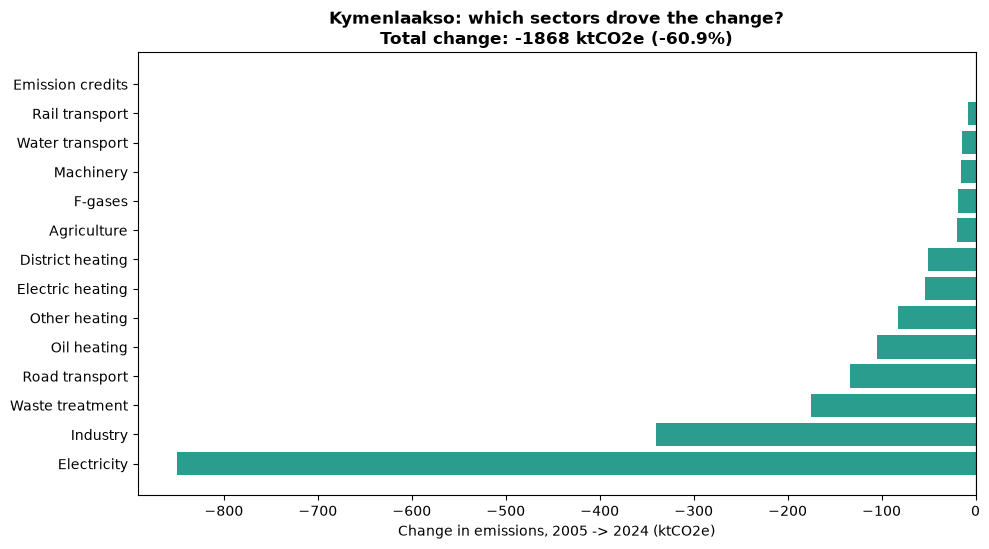

year               2005   2024  delta
sector                               
Electricity       987.6  138.2 -849.4
Industry          612.9  272.5 -340.4
Waste treatment   306.3  131.3 -175.0
Road transport    417.9  283.8 -134.1
Oil heating       135.2   30.0 -105.2
Other heating     124.4   41.5  -82.9
Electric heating   71.3   17.1  -54.2
District heating  119.8   69.7  -50.1
Agriculture       138.5  118.8  -19.7
F-gases            38.2   19.2  -19.0
Machinery          75.0   59.5  -15.5
Water transport    26.9   12.6  -14.3
Rail transport     15.9    7.4   -8.5
Emission credits    0.0    0.0    0.0

Largest single contributor to the change: Electricity (-849 ktCO2e, 45% of the total change)


In [16]:
DRIVER_REGION = change["region"].iloc[0]   # <- change to inspect any region; defaults to the biggest mover

driver_data = ghg_long[(ghg_long["region"] == DRIVER_REGION)
                       & (ghg_long["year"].isin([BASE_YEAR, COMPARE_YEAR]))]
driver_pivot = driver_data.pivot_table(index="sector", columns="year", values="value_ktco2e", aggfunc="sum")

if BASE_YEAR in driver_pivot.columns and COMPARE_YEAR in driver_pivot.columns:
    driver_pivot["delta"] = driver_pivot[COMPARE_YEAR] - driver_pivot[BASE_YEAR]
    driver_pivot = driver_pivot.sort_values("delta")

    total_delta = driver_pivot["delta"].sum()
    fig, ax = plt.subplots(figsize=(10, max(5, len(driver_pivot)*0.4)))
    colors = ["#2a9d8f" if v < 0 else "#e76f51" for v in driver_pivot["delta"]]
    ax.barh(driver_pivot.index, driver_pivot["delta"], color=colors)
    ax.axvline(0, color="black", lw=0.8)
    ax.set_xlabel(f"Change in emissions, {BASE_YEAR} -> {COMPARE_YEAR} (ktCO2e)")
    ax.set_title(f"{DRIVER_REGION}: which sectors drove the change?\n"
                 f"Total change: {total_delta:+.0f} ktCO2e ({total_delta/driver_pivot[BASE_YEAR].sum()*100:+.1f}%)",
                 fontweight="bold")
    plt.tight_layout()
    plt.savefig(os.path.join(output_dir, "section7d_sector_drivers.png"), dpi=130, bbox_inches="tight")
    plt.show()

    print(driver_pivot.sort_values("delta").to_string())
    top_driver = driver_pivot["delta"].idxmin() if total_delta < 0 else driver_pivot["delta"].idxmax()
    print(f"\nLargest single contributor to the change: {top_driver} "
          f"({driver_pivot.loc[top_driver,'delta']:+.0f} ktCO2e, "
          f"{driver_pivot.loc[top_driver,'delta']/total_delta*100:.0f}% of the total change)")
else:
    print(f"Missing data for {BASE_YEAR} or {COMPARE_YEAR} for {DRIVER_REGION}.")


---
## 8 — Sector Similarity: Which Sectors Move Together
Section 3 asked "which *regions* move alike". This asks the same question about *sectors*:
does `Electricity` rise and fall in the same years as `District heating`? That would suggest a
shared driver (e.g. cold winters raise both, or grid decarbonisation cuts both together). Two
sectors that move in **opposite** directions might indicate substitution (e.g. `Oil heating`
falling while `District heating` or `Electric heating` rises, as households switch systems).

We aggregate across all loaded regions (national totals by sector, by year) and correlate each
sector's time series against every other sector's.


Excluding zero-variance sectors from correlation: ['Emission credits']


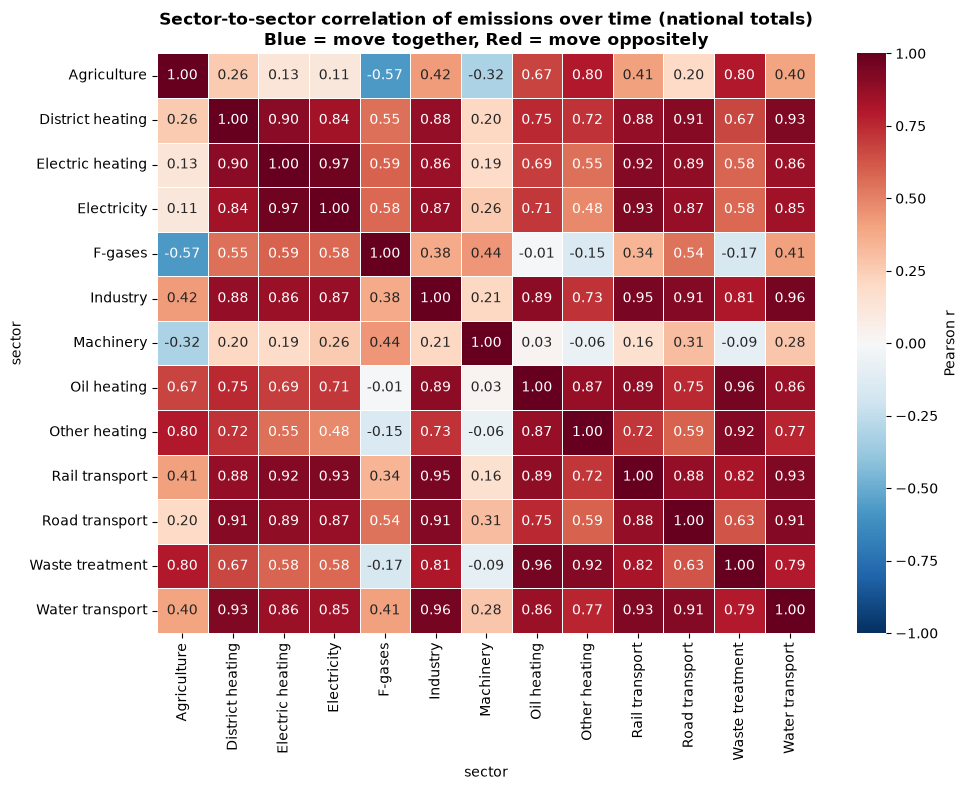

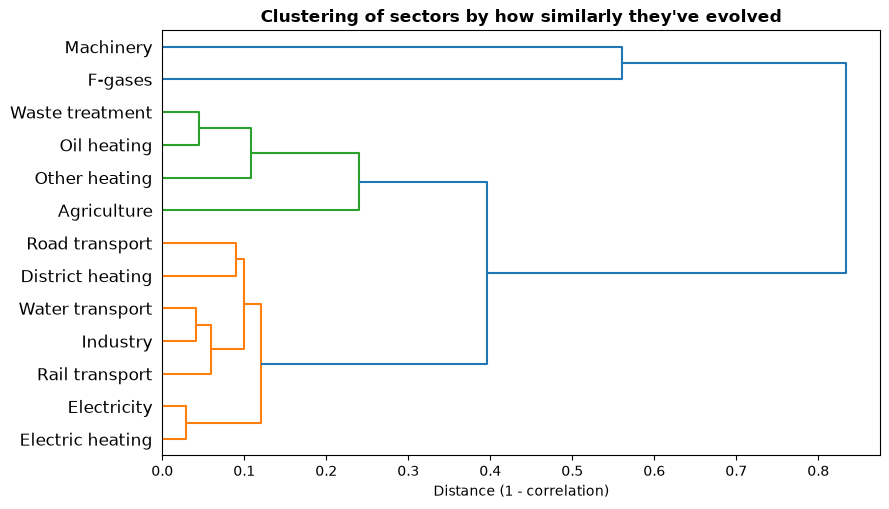

Most similar sector pairs (move together):
sector            sector         
Electric heating  Electricity        0.970698
Industry          Water transport    0.958944
Oil heating       Waste treatment    0.955519
Industry          Rail transport     0.950679
District heating  Water transport    0.933626
Electricity       Rail transport     0.932806
Rail transport    Water transport    0.930112
Electric heating  Rail transport     0.918717
dtype: float64

Most opposite sector pairs (move apart -- possible substitution):
sector       sector         
Agriculture  F-gases           -0.574147
             Machinery         -0.316721
F-gases      Waste treatment   -0.166951
             Other heating     -0.150176
Machinery    Waste treatment   -0.090166
             Other heating     -0.063061
F-gases      Oil heating       -0.014841
Machinery    Oil heating        0.029237
dtype: float64


In [17]:
national_sector_year_corr_input = (ghg_long.groupby(["year","sector"])["value_ktco2e"]
                                   .sum().reset_index()
                                   .pivot(index="year", columns="sector", values="value_ktco2e"))

# Drop sectors with zero variance (e.g. a sector that's all zero, like an unused
# "Emission credits" row) -- correlation against a constant series is undefined (NaN)
# and would break the clustering step below.
sector_std = national_sector_year_corr_input.std()
flat_sectors = sector_std[sector_std == 0].index.tolist()
if flat_sectors:
    print(f"Excluding zero-variance sectors from correlation: {flat_sectors}")
national_sector_year_corr_input = national_sector_year_corr_input.drop(columns=flat_sectors)

if national_sector_year_corr_input.shape[1] < 2:
    print("Need at least 2 (non-constant) sectors present to compute correlation.")
else:
    sector_corr = national_sector_year_corr_input.corr()

    fig, ax = plt.subplots(figsize=(10, 8))
    sns.heatmap(sector_corr, cmap="RdBu_r", center=0, vmin=-1, vmax=1, annot=True, fmt=".2f",
                linewidths=0.4, ax=ax, cbar_kws={"label": "Pearson r"})
    ax.set_title("Sector-to-sector correlation of emissions over time (national totals)\n"
                 "Blue = move together, Red = move oppositely", fontweight="bold")
    plt.tight_layout()
    plt.savefig(os.path.join(output_dir, "section8_sector_correlation_heatmap.png"), dpi=130, bbox_inches="tight")
    plt.show()

    dist = 1 - sector_corr
    condensed = squareform(dist.values, checks=False)
    Z = linkage(condensed, method="average")
    fig, ax = plt.subplots(figsize=(9, max(4, len(sector_corr)*0.4)))
    dendrogram(Z, labels=sector_corr.columns.tolist(), orientation="right", ax=ax, color_threshold=0.3)
    ax.set_title("Clustering of sectors by how similarly they've evolved", fontweight="bold")
    ax.set_xlabel("Distance (1 - correlation)")
    plt.tight_layout()
    plt.savefig(os.path.join(output_dir, "section8_sector_dendrogram.png"), dpi=130, bbox_inches="tight")
    plt.show()

    print("Most similar sector pairs (move together):")
    corr_flat = sector_corr.where(np.triu(np.ones(sector_corr.shape), k=1).astype(bool)).stack()
    print(corr_flat.sort_values(ascending=False).head(8))
    print("\nMost opposite sector pairs (move apart -- possible substitution):")
    print(corr_flat.sort_values().head(8))


### 8b — Detrended version: correlation of year-on-year *changes*, not levels
**Why this matters:** almost every sector has trended downward for 20 years (grid
decarbonisation, efficiency, policy). Correlating the raw *levels* of two declining series
makes them look highly correlated even if their year-to-year wiggles have nothing to do with
each other — they're both just "generally falling". Correlating the **year-on-year % change**
instead removes that shared trend and reveals which sectors actually move together for the same
reason in the same year (e.g. both jump in a cold winter, or both dip in the same recession) --
this is the "what information do they preserve" question: shared short-term shocks, not just a
shared long-term direction.


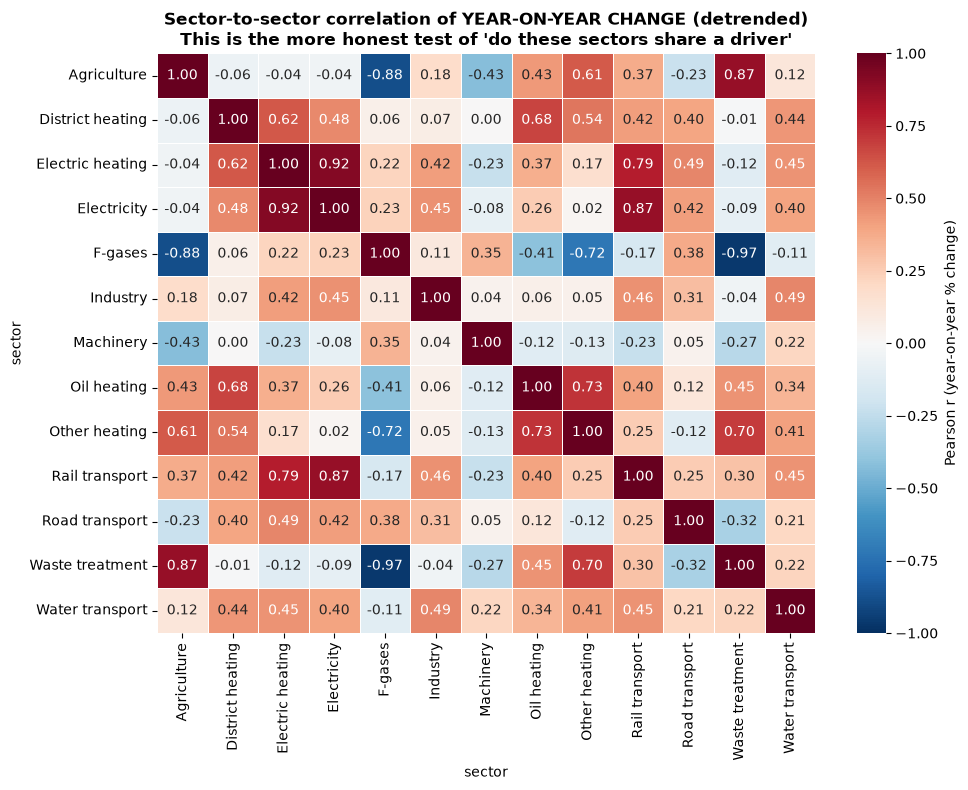

                           level_corr_mean  change_corr_mean
all sector pairs, average         0.576511          0.183048

If 'level_corr_mean' is much higher than 'change_corr_mean', most of the apparent similarity in 8a was the shared downward trend, not real shared shocks.


In [18]:
sector_pctchange = national_sector_year_corr_input.pct_change().replace([np.inf, -np.inf], np.nan).dropna(how="all")
sector_pctchange_corr = sector_pctchange.corr()

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(sector_pctchange_corr, cmap="RdBu_r", center=0, vmin=-1, vmax=1, annot=True, fmt=".2f",
            linewidths=0.4, ax=ax, cbar_kws={"label": "Pearson r (year-on-year % change)"})
ax.set_title("Sector-to-sector correlation of YEAR-ON-YEAR CHANGE (detrended)\n"
             "This is the more honest test of 'do these sectors share a driver'", fontweight="bold")
plt.tight_layout()
plt.savefig(os.path.join(output_dir, "section8b_sector_correlation_detrended.png"), dpi=130, bbox_inches="tight")
plt.show()

level_vs_change = pd.DataFrame({
    "level_corr_mean": sector_corr.where(np.triu(np.ones(sector_corr.shape), k=1).astype(bool)).stack().mean(),
    "change_corr_mean": sector_pctchange_corr.where(np.triu(np.ones(sector_pctchange_corr.shape), k=1).astype(bool)).stack().mean(),
}, index=["all sector pairs, average"])
print(level_vs_change)
print("\nIf 'level_corr_mean' is much higher than 'change_corr_mean', most of the apparent "
      "similarity in 8a was the shared downward trend, not real shared shocks.")


---
## 9 — Geographic Proximity: Are Neighbouring Regions Actually Similar?
**Hypothesis to test:** regions that are physically close to each other might also be similar in
CO2 per capita, population, and GDP — because they share climate, transport links, and often
industry type. We test this directly rather than assume it:

1. Get each region's centroid from the same boundary geometry used for the map (Section 4)
2. Compute the distance between every pair of regions
3. Mark pairs closer than `NEIGHBOR_DISTANCE_KM` as "geographically close" — try a few thresholds;
   there's no single correct value, so treat this as exploratory
4. For `FOCUS_YEAR`, compare each close pair's per-capita CO2, population, and GDP per capita
5. Test the hypothesis across **all** pairs, not just close ones: does distance actually predict
   similarity, or not? A weak/no relationship is itself a useful, reportable finding.


8 of 171 region pairs are within 100 km of each other.

Geographically close pairs and how similar they are:
          region_a      region_b  distance_km  diff_per_capita_tco2e  diff_population  diff_gdp_per_capita
South Ostrobothnia  Ostrobothnia    59.876208                    3.5          11180.0                  NaN
           Uusimaa    Kanta-Häme    66.340960                    2.2        1612845.0                  NaN
     South Karelia    South Savo    77.004784                    3.3           4293.0                  NaN
       Päijät-Häme   Kymenlaakso    78.275341                    2.2          47193.0                  NaN
        Kanta-Häme   Päijät-Häme    82.901408                    0.7          35180.0                  NaN
       Kymenlaakso South Karelia    87.613139                    2.2          32359.0                  NaN
         Satakunta     Pirkanmaa    88.028501                    3.1         334145.0                  NaN
        Kanta-Häme     Pirkanmaa   

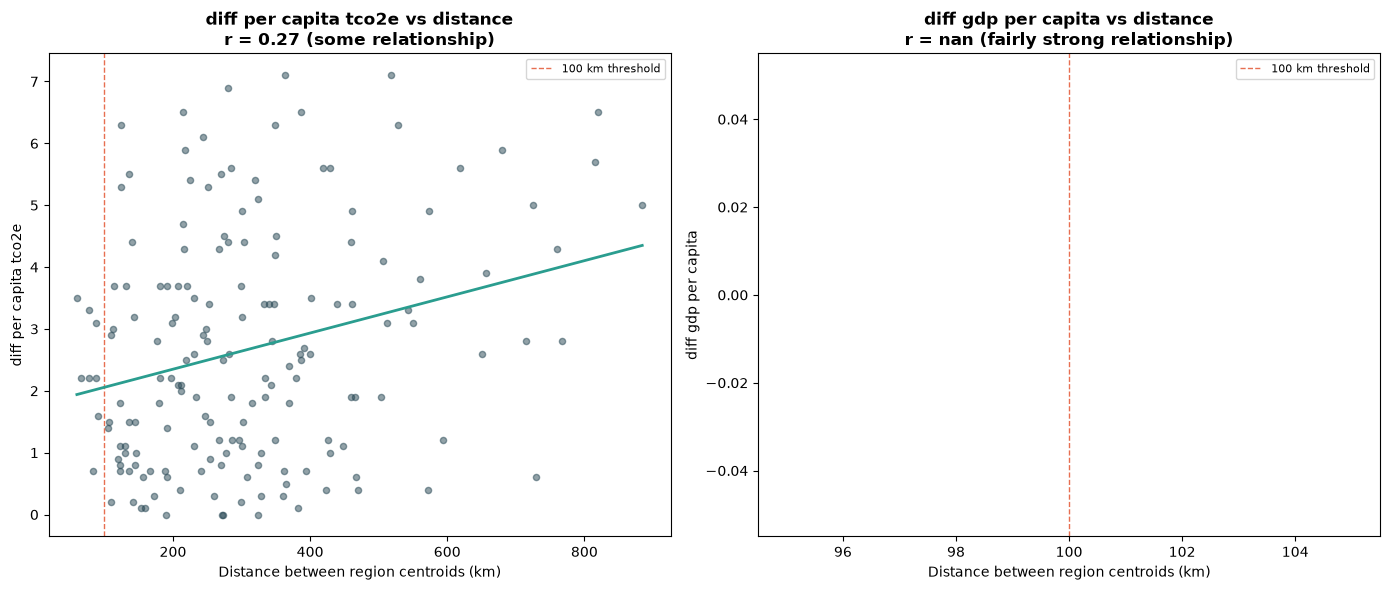

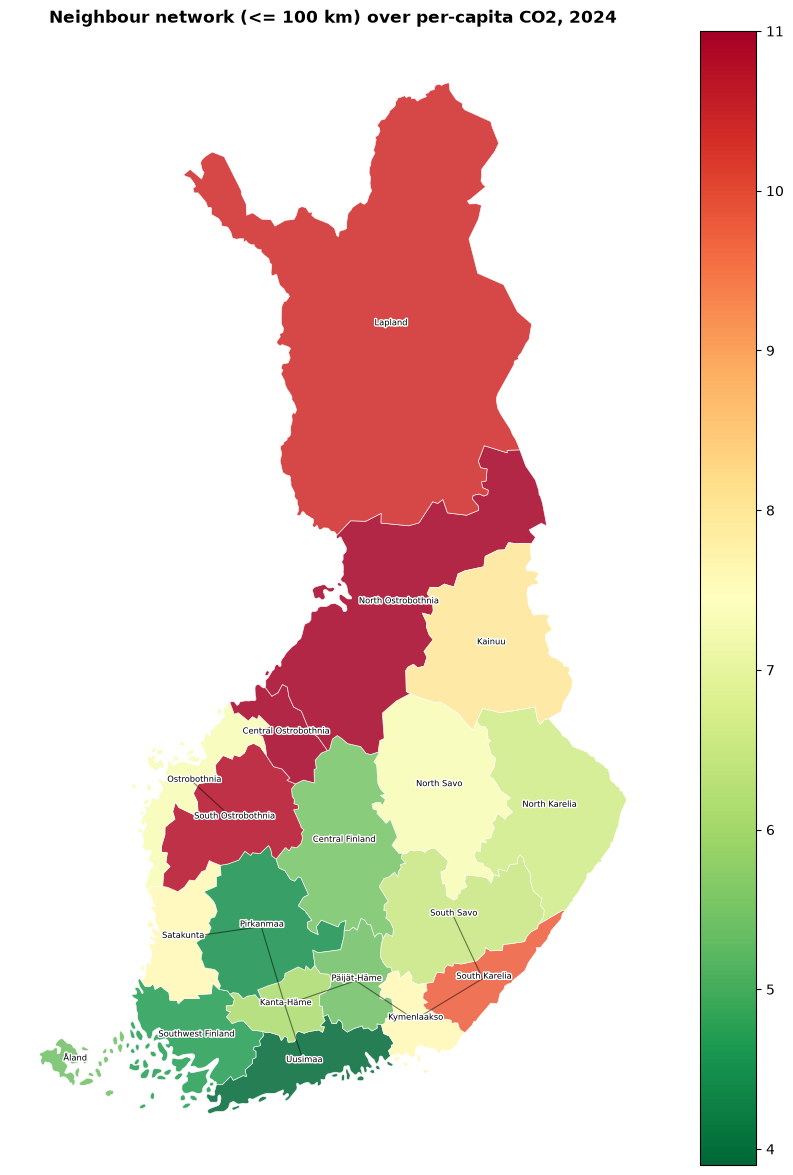

In [31]:
try:
    geo = fetch_region_geometry()

    # EPSG:3067 (TM35FIN) is already a metric projection for Finland, so centroid
    # coordinates are in metres -- no reprojection needed for distance calculations.
    geo["centroid"] = geo.geometry.centroid
    geo["region_key"] = geo["region_key"]

    snap = summary[summary["year"] == FOCUS_YEAR].copy()
    snap["region_key"] = snap["region"].apply(normalize_name)
    geo_snap = geo.merge(snap, on="region_key", how="inner")

    if gdp_merged is not None:
        gdp_snap = gdp_merged[gdp_merged["year"] == FOCUS_YEAR][["region","gdp_per_capita_eur"]]
        gdp_snap["region_key"] = gdp_snap["region"].apply(normalize_name)
        geo_snap = geo_snap.merge(gdp_snap[["region_key","gdp_per_capita_eur"]],
                                  on="region_key", how="left")

    n = len(geo_snap)
    if n < 2:
        print("Need at least 2 matched regions with geometry to run this section.")
    else:
        pairs = []
        for i in range(n):
            for j in range(i+1, n):
                a, b = geo_snap.iloc[i], geo_snap.iloc[j]
                dist_km = a["centroid"].distance(b["centroid"]) / 1000
                row = {
                    "region_a": a["region"], "region_b": b["region"], "distance_km": dist_km,
                    "diff_per_capita_tco2e": abs(a["per_capita_tco2e"] - b["per_capita_tco2e"]),
                    "diff_population": abs(a["population"] - b["population"]),
                }
                if "gdp_per_capita_eur" in geo_snap.columns:
                    row["diff_gdp_per_capita"] = abs(a["gdp_per_capita_eur"] - b["gdp_per_capita_eur"])
                pairs.append(row)
        pairs_df = pd.DataFrame(pairs)
        neighbours = pairs_df[pairs_df["distance_km"] <= NEIGHBOR_DISTANCE_KM].sort_values("distance_km")

        print(f"{len(neighbours)} of {len(pairs_df)} region pairs are within "
              f"{NEIGHBOR_DISTANCE_KM} km of each other.\n")
        print("Geographically close pairs and how similar they are:")
        print(neighbours.to_string(index=False))

        # Does distance actually predict similarity? Test across ALL pairs.
        metrics_to_test = [c for c in ["diff_per_capita_tco2e", "diff_gdp_per_capita"] if c in pairs_df.columns]
        fig, axes = plt.subplots(1, len(metrics_to_test), figsize=(7*len(metrics_to_test), 6))
        if len(metrics_to_test) == 1:
            axes = [axes]
        for ax, metric in zip(axes, metrics_to_test):
            r = pairs_df["distance_km"].corr(pairs_df[metric])
            ax.scatter(pairs_df["distance_km"], pairs_df[metric], alpha=0.5, s=20, color="#264653")
            ax.axvline(NEIGHBOR_DISTANCE_KM, color="#e76f51", linestyle="--", lw=1,
                      label=f"{NEIGHBOR_DISTANCE_KM} km threshold")
            z = np.polyfit(pairs_df["distance_km"], pairs_df[metric], 1)
            xs = np.linspace(pairs_df["distance_km"].min(), pairs_df["distance_km"].max(), 50)
            ax.plot(xs, np.poly1d(z)(xs), color="#2a9d8f", lw=2)
            ax.set_xlabel("Distance between region centroids (km)")
            ax.set_ylabel(metric.replace("_"," "))
            ax.set_title(f"{metric.replace('_',' ')} vs distance\nr = {r:.2f}"
                        + (" (weak/no relationship)" if abs(r) < 0.2 else
                           " (some relationship)" if abs(r) < 0.5 else " (fairly strong relationship)"),
                        fontweight="bold")
            ax.legend(fontsize=8)
        plt.tight_layout()
        plt.savefig(os.path.join(output_dir, "section9_distance_vs_similarity.png"), dpi=130, bbox_inches="tight")
        plt.show()

        # Network view on the actual map: nodes = regions, edges = "close" pairs
        fig, ax = plt.subplots(figsize=(9, 12))
        geo_snap.plot(column="per_capita_tco2e", cmap="RdYlGn_r", ax=ax, edgecolor="white",
                     linewidth=0.5, alpha=0.85, legend=True)
        for _, row in neighbours.iterrows():
            pa = geo_snap[geo_snap["region"] == row["region_a"]]["centroid"].iloc[0]
            pb = geo_snap[geo_snap["region"] == row["region_b"]]["centroid"].iloc[0]
            ax.plot([pa.x, pb.x], [pa.y, pb.y], color="black", lw=0.8, alpha=0.5)
        for _, row in geo_snap.iterrows():
            ax.annotate(row["region"], (row["centroid"].x, row["centroid"].y), fontsize=6,
                       ha="center", path_effects=[pe.withStroke(linewidth=2, foreground="white")])
        ax.set_title(f"Neighbour network (<= {NEIGHBOR_DISTANCE_KM} km) over per-capita CO2, {FOCUS_YEAR}",
                    fontweight="bold")
        ax.set_axis_off()
        plt.tight_layout()
        plt.savefig(os.path.join(output_dir, "section9_neighbour_network_map.png"), dpi=150, bbox_inches="tight")
        plt.show()

except Exception as e:
    print(f"Geographic proximity analysis needs the region geometry, which failed to load ({e}). "
          f"Install geopandas + requests and ensure you have internet access to geo.stat.fi.")


---
## Summary

Once all 19 region files + the GDP file are in place, this notebook gives your supervisor:
1. A **regional emissions leaderboard** for any chosen `FOCUS_YEAR`, total and per-capita
2. A **region similarity/clustering view** of which regions decarbonise alike
3. A **choropleth map** of Finland, labelled, for any chosen `FOCUS_YEAR`
4. **GDP vs CO2**, redesigned as trends + trajectory arrows, with clear nominal-vs-real unit
   definitions, for any `BASE_YEAR`/`COMPARE_YEAR`
5. **Sector breakdown, evolution over time, and subclass drill-down** — what's inside each
   sector and how it's changing year by year
6. A **decarbonisation ranking, year-on-year heatmap, rate-of-change (derivative), and
   sector-driver breakdown** — not just "what changed" but "when" and "because of what"
7. **Sector similarity** — which sectors move together nationally, and what that implies
   about shared underlying drivers
8. A **geographic proximity test** — whether physically close regions are actually similar
   in emissions, population, or GDP

Change `BASE_YEAR` / `COMPARE_YEAR` / `FOCUS_YEAR` / `NEIGHBOR_DISTANCE_KM` in the Parameters
cell (right after Section 1) and re-run to get every section for a different year or window —
nothing else in the notebook needs editing.

All outputs save to `outputs_regional/*.png` for dropping into a report or slide deck.
